In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

In [2]:
data=pd.read_csv('/content/forest_cover_dataset.csv')

**Preprocessing**

In [3]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [4]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   0       581012 non-null  int64
 1   1       581012 non-null  int64
 2   2       581012 non-null  int64
 3   3       581012 non-null  int64
 4   4       581012 non-null  int64
 5   5       581012 non-null  int64
 6   6       581012 non-null  int64
 7   7       581012 non-null  int64
 8   8       581012 non-null  int64
 9   9       581012 non-null  int64
 10  10      581012 non-null  int64
 11  11      581012 non-null  int64
 12  12      581012 non-null  int64
 13  13      581012 non-null  int64
 14  14      581012 non-null  int64
 15  15      581012 non-null  int64
 16  16      581012 non-null  int64
 17  17      581012 non-null  int64
 18  18      581012 non-null  int64
 19  19      581012 non-null  int64
 20  20      581012 non-null  int64
 21  21      581012 non-null  int64
 22  22      581012 non-n

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [5]:
data.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [6]:
print('Number of unique values per column:')
for col in data.columns:
    if data[col].nunique() < 20:
        print(f"Column {col}: {data[col].nunique()} unique values")

Number of unique values per column:
Column 10: 2 unique values
Column 11: 2 unique values
Column 12: 2 unique values
Column 13: 2 unique values
Column 14: 2 unique values
Column 15: 2 unique values
Column 16: 2 unique values
Column 17: 2 unique values
Column 18: 2 unique values
Column 19: 2 unique values
Column 20: 2 unique values
Column 21: 2 unique values
Column 22: 2 unique values
Column 23: 2 unique values
Column 24: 2 unique values
Column 25: 2 unique values
Column 26: 2 unique values
Column 27: 2 unique values
Column 28: 2 unique values
Column 29: 2 unique values
Column 30: 2 unique values
Column 31: 2 unique values
Column 32: 2 unique values
Column 33: 2 unique values
Column 34: 2 unique values
Column 35: 2 unique values
Column 36: 2 unique values
Column 37: 2 unique values
Column 38: 2 unique values
Column 39: 2 unique values
Column 40: 2 unique values
Column 41: 2 unique values
Column 42: 2 unique values
Column 43: 2 unique values
Column 44: 2 unique values
Column 45: 2 unique

In [7]:
data.duplicated().sum()

np.int64(0)

**EDA**

**Data Distribution**

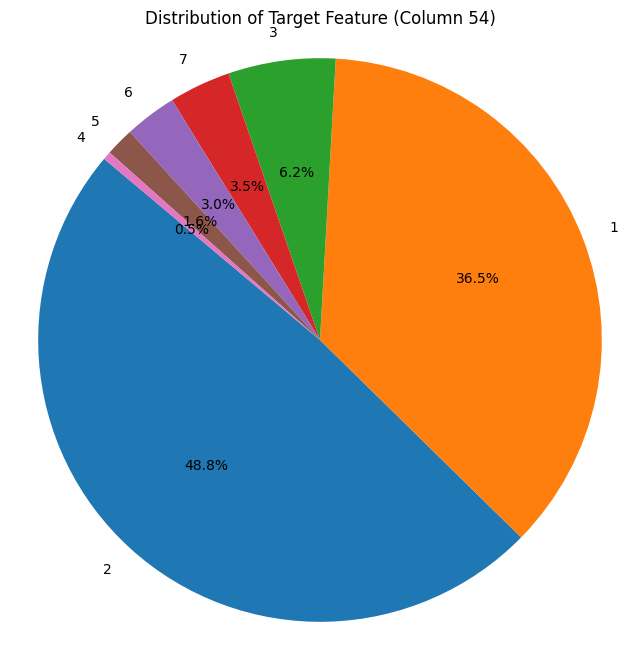

In [8]:
target_counts = data['54'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Target Feature (Column 54)')
plt.axis('equal')
plt.show()

**Handle the distribution by class weights**

In [9]:
from sklearn.utils import class_weight
y = data['54']

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

class_weight_dict = dict(zip(np.unique(y), class_weights))

print("Calculated Class Weights:")
print(class_weight_dict)

Calculated Class Weights:
{np.int64(1): np.float64(0.391813228312473), np.int64(2): np.float64(0.292980661154441), np.int64(3): np.float64(2.321466529219508), np.int64(4): np.float64(30.215403817151177), np.int64(5): np.float64(8.743465109629652), np.int64(6): np.float64(4.77927761189119), np.int64(7): np.float64(4.046890018806157)}


**Correlation**

Correlation with Target Feature (Column 54):
54    1.000000
13    0.323200
23    0.243876
51    0.160170
52    0.155668
2     0.148285
53    0.128351
15    0.118135
19    0.112958
17    0.099672
14    0.090828
30    0.090582
4     0.081664
48    0.080315
50    0.080271
18    0.077890
16    0.068064
12    0.066846
27    0.065562
24    0.035379
49    0.025397
26    0.024404
1     0.017080
29    0.009844
31    0.007390
28    0.006425
47    0.004643
39   -0.000375
20   -0.000496
41   -0.001702
21   -0.003667
22   -0.006110
38   -0.006449
43   -0.010436
40   -0.014407
3    -0.020317
25   -0.023601
34   -0.025400
33   -0.028665
6    -0.035415
32   -0.036452
11   -0.048059
8    -0.048290
46   -0.062502
44   -0.065347
37   -0.068746
45   -0.075562
7    -0.096426
9    -0.108936
42   -0.124933
36   -0.135055
35   -0.141746
5    -0.153450
10   -0.203913
0    -0.269554
Name: 54, dtype: float64


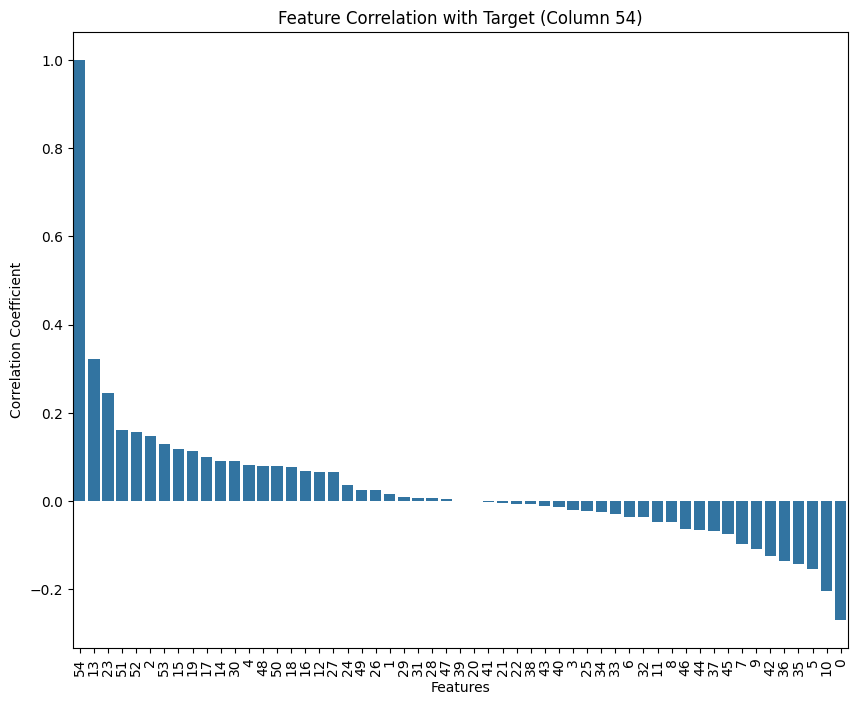

In [10]:
correlation_matrix = data.corr()

# Get correlation of all features with the target feature '54'
target_correlation = correlation_matrix['54'].sort_values(ascending=False)

print("Correlation with Target Feature (Column 54):")
print(target_correlation)

# Optionally, visualize the top correlations
plt.figure(figsize=(10, 8))
sns.barplot(x=target_correlation.index, y=target_correlation.values)
plt.title('Feature Correlation with Target (Column 54)')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90)
plt.show()

In [11]:
target_col = '54'
feature_cols = [col for col in data.columns if col != target_col]
class_wise_mean = data.groupby(target_col)[feature_cols].mean()
class_wise_mean.head()


,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
54,,,,,,,,,,,,,,,,,,,,,
1,3128.644888,156.138227,13.127110,270.555245,42.156939,2614.834517,211.998782,223.430211,143.875038,2009.253517,...,0.056000,0.100821,0.085668,0.000444,0.004395,0.000066,0.0,0.041206,0.037207,0.022781
2,2920.936061,152.060515,13.550499,279.916442,45.884219,2429.530799,213.844423,225.326596,142.983466,2168.154849,...,0.046625,0.104327,0.089333,0.005051,0.000042,0.000148,0.0,0.002612,0.001264,0.001172
3,2394.509845,176.372490,20.770208,210.276473,62.446915,943.940734,201.918415,215.826537,140.367176,910.955949,...,0.000000,0.002965,0.000140,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
4,2223.939934,137.139425,18.528941,106.934838,41.186749,914.199490,228.345832,216.997088,111.392792,859.124135,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
5,2787.417571,139.283051,16.641315,212.354893,50.610344,1349.765722,223.474876,219.035816,121.920889,1577.719794,...,0.032550,0.048457,0.054567,0.002107,0.000000,0.000000,0.0,0.000000,0.000000,0.000000


In [12]:
feature_support = {}

for feature in feature_cols:
    supporting_class = class_wise_mean[feature].idxmax()
    feature_support[feature] = supporting_class
support_df = (
    pd.DataFrame.from_dict(feature_support, orient="index", columns=["Most_Supported_Class"])
    .reset_index()
    .rename(columns={"index": "Feature"})
)
support_df.head(40)


,Feature,Most_Supported_Class
0,0,7
1,1,6
2,2,3
3,3,7
4,4,7
5,5,7
6,6,4
7,7,2
8,8,6
9,9,2


**classes & feature relation**

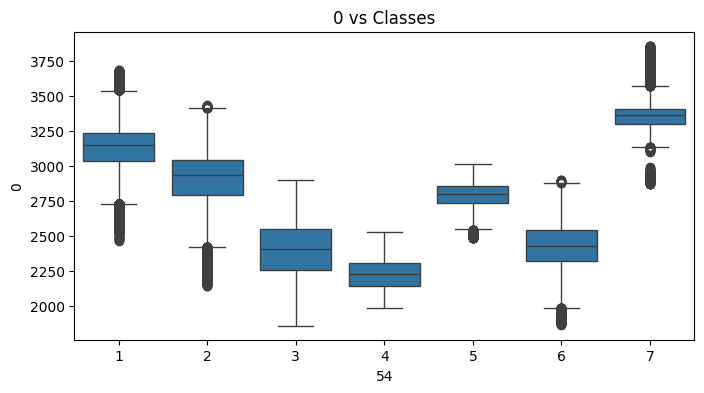

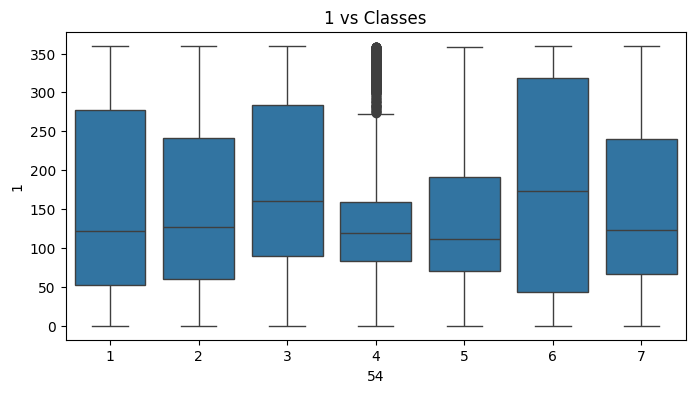

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

for feature in feature_cols[:2]:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=target_col, y=feature, data=data)
    plt.title(f"{feature} vs Classes")
    plt.show()

In [14]:
binary_features = [col for col in feature_cols if data[col].nunique() == 2]

binary_class_mean = data.groupby(target_col)[binary_features].mean()
binary_class_mean.head()


,10,11,12,13,14,15,16,17,18,19,...,44,45,46,47,48,49,50,51,52,53
54,,,,,,,,,,,,,,,,,,,,,
1,0.499042,0.087779,0.413180,0.000000,0.000000,0.000000,0.000000,0.000859,0.000000,0.000000,...,0.056000,0.100821,0.085668,0.000444,0.004395,0.000066,0.0,0.041206,0.037207,0.022781
2,0.516048,0.031715,0.441555,0.010681,0.000000,0.003007,0.004204,0.011475,0.000000,0.003219,...,0.046625,0.104327,0.089333,0.005051,0.000042,0.000148,0.0,0.002612,0.001264,0.001172
3,0.000000,0.000000,0.399955,0.600045,0.058763,0.139593,0.067433,0.209795,0.027046,0.111680,...,0.000000,0.002965,0.000140,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,1.000000,0.064798,0.041864,0.370586,0.061158,0.017474,0.116491,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
5,0.398293,0.000000,0.601707,0.000000,0.000000,0.027810,0.000000,0.061624,0.000000,0.000000,...,0.032550,0.048457,0.054567,0.002107,0.000000,0.000000,0.0,0.000000,0.000000,0.000000


**Boxplot to check outliers**

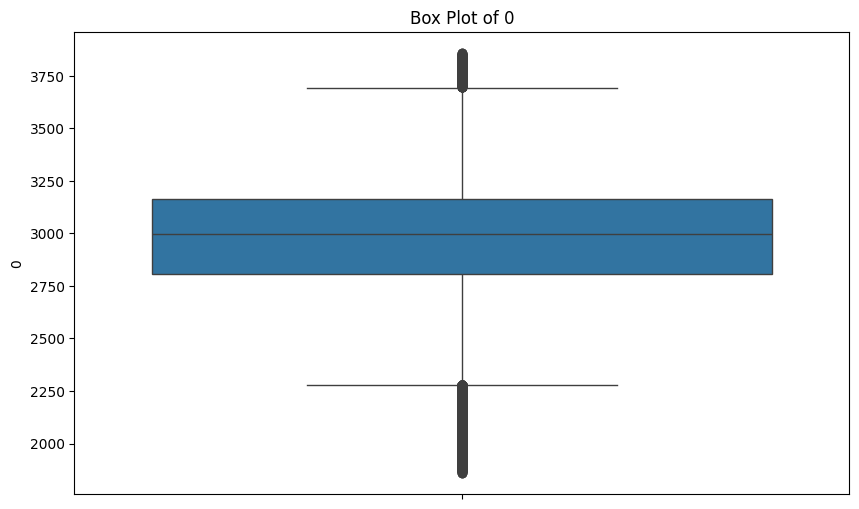

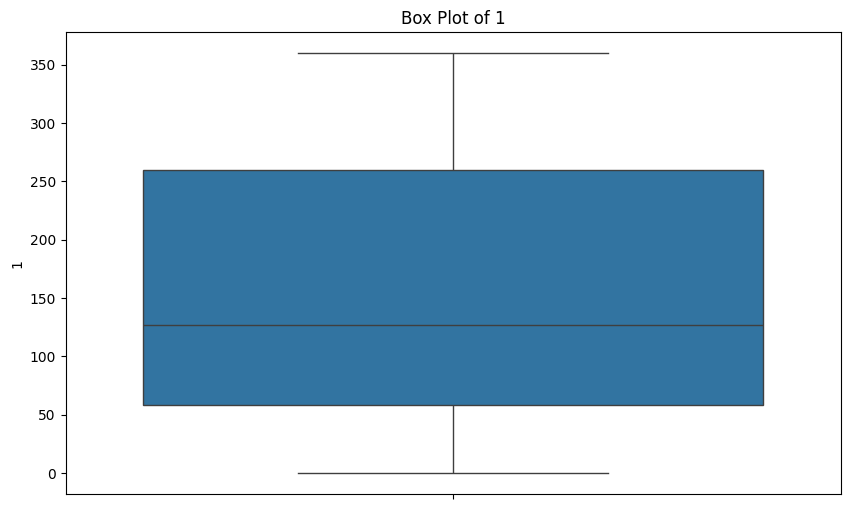

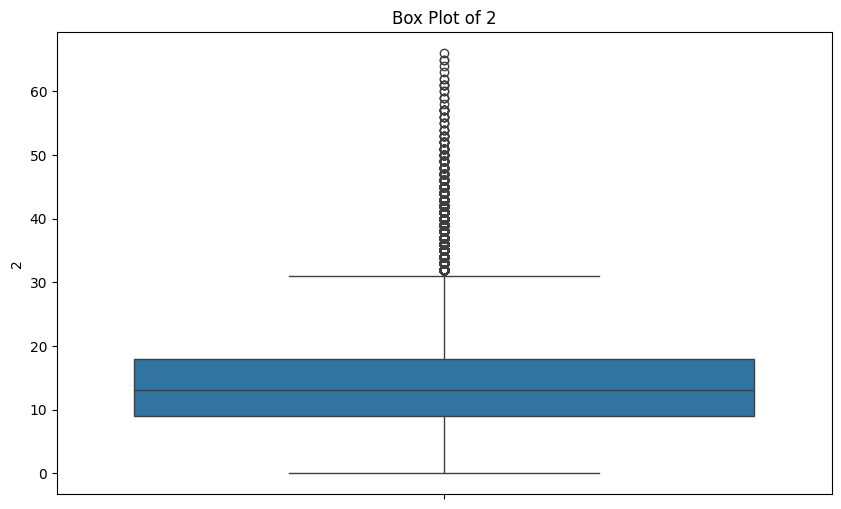

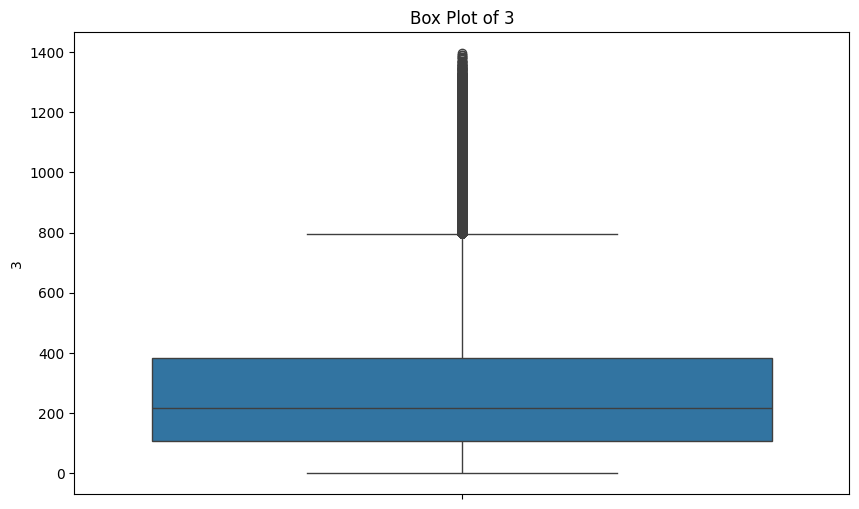

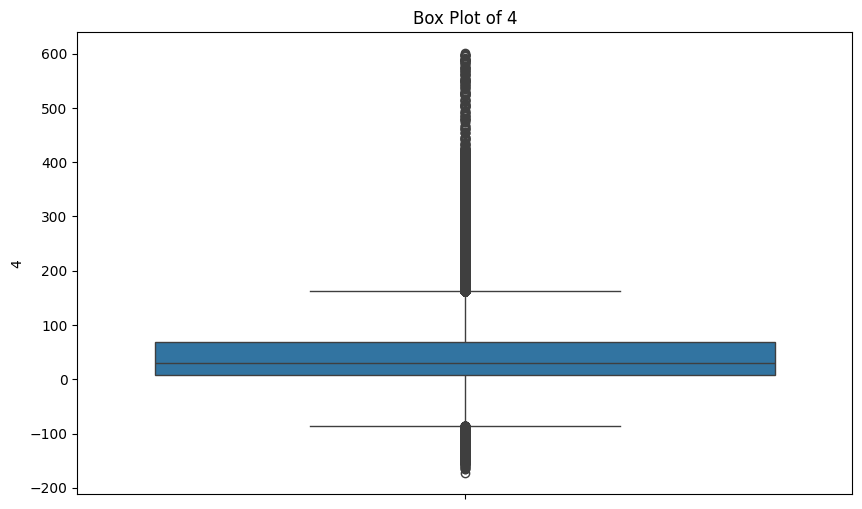

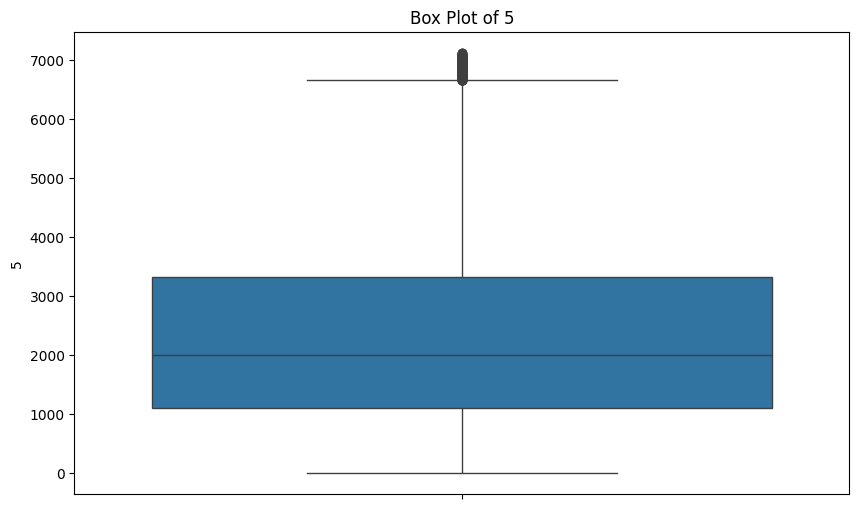

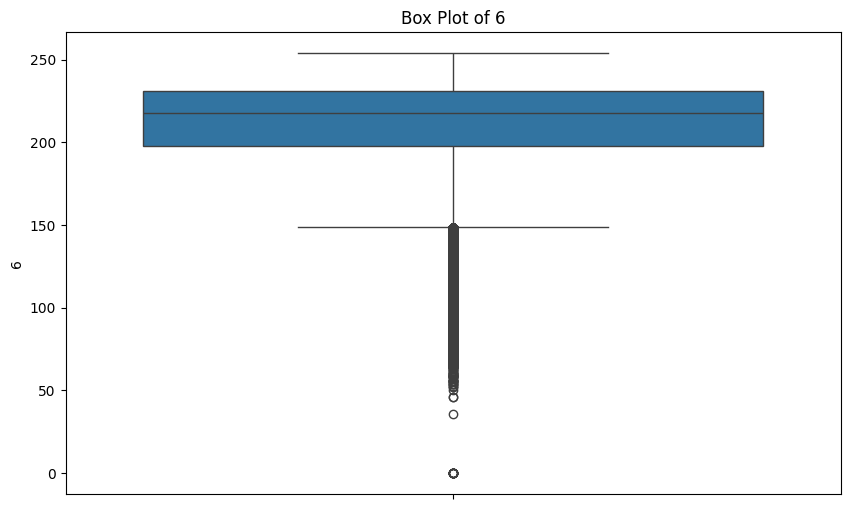

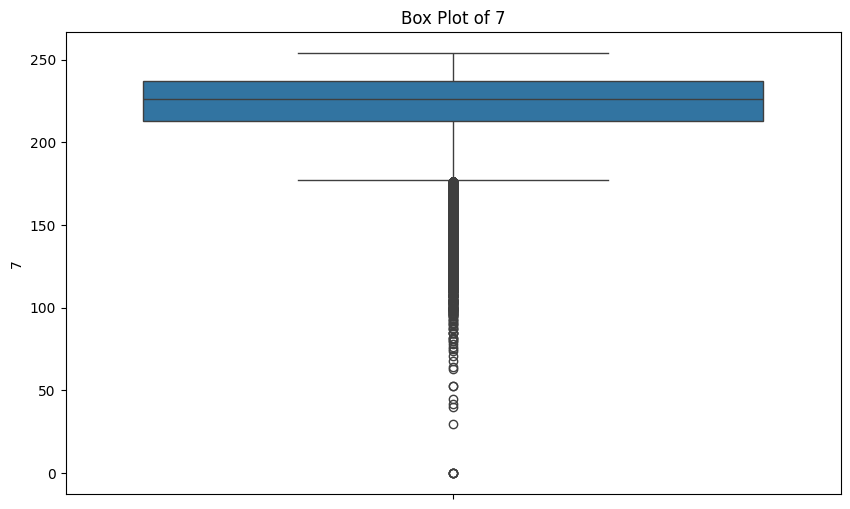

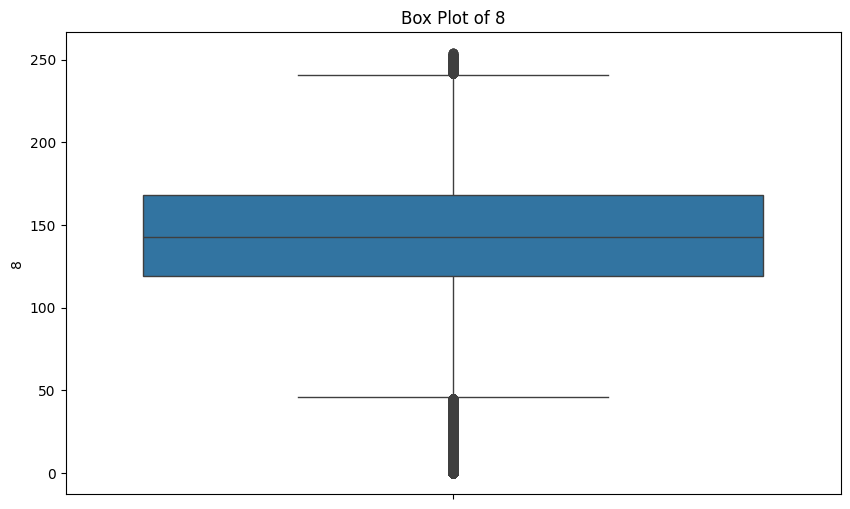

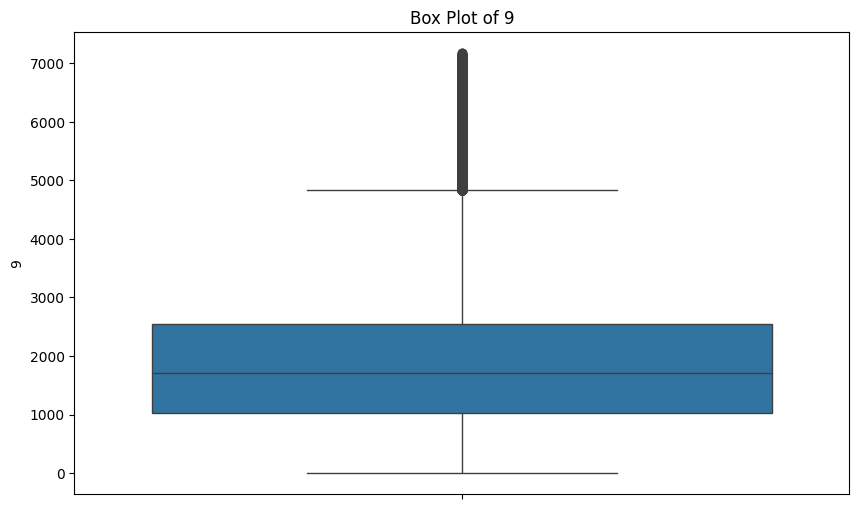

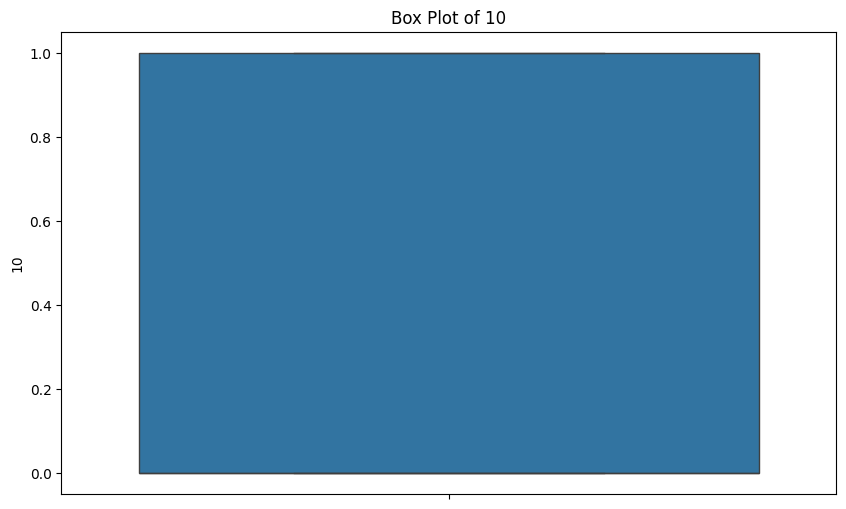

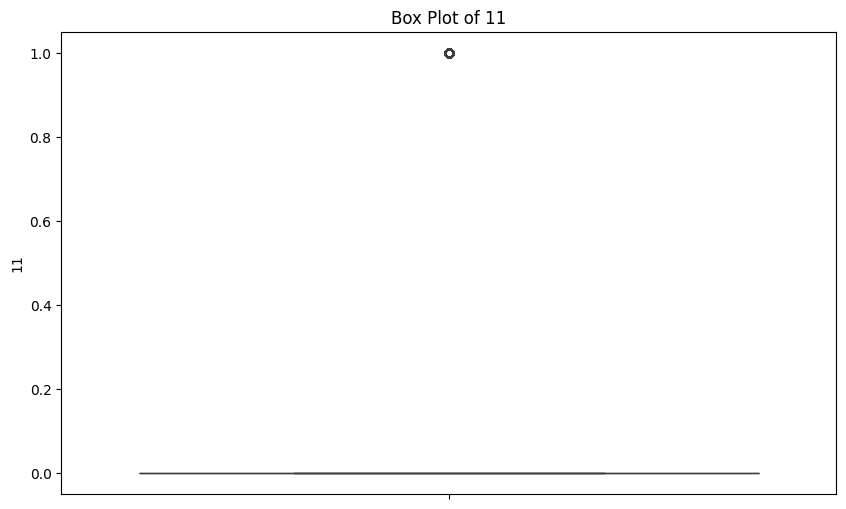

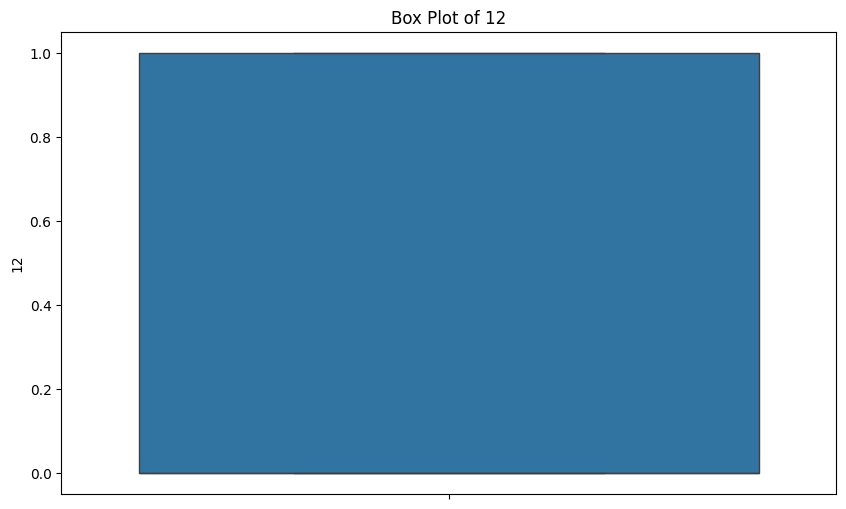

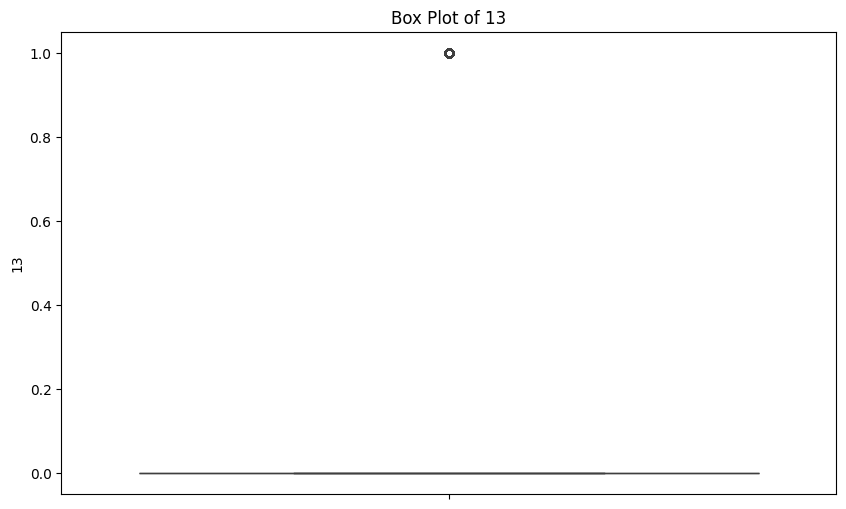

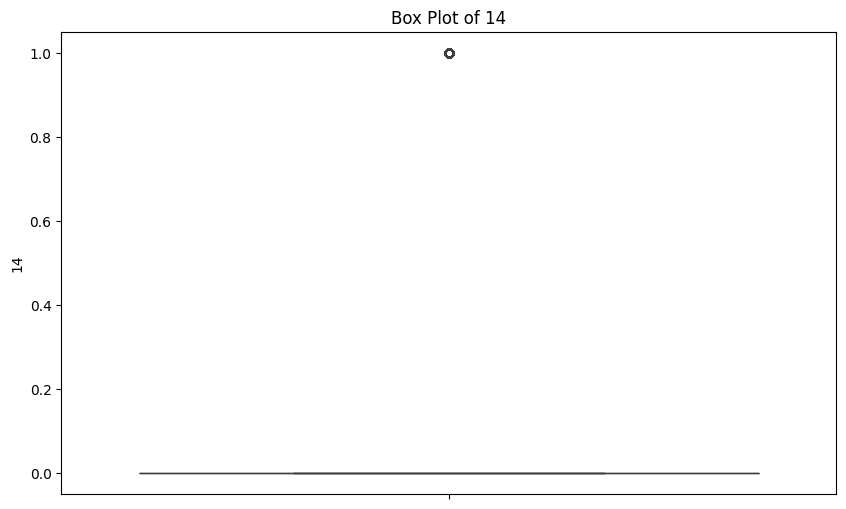

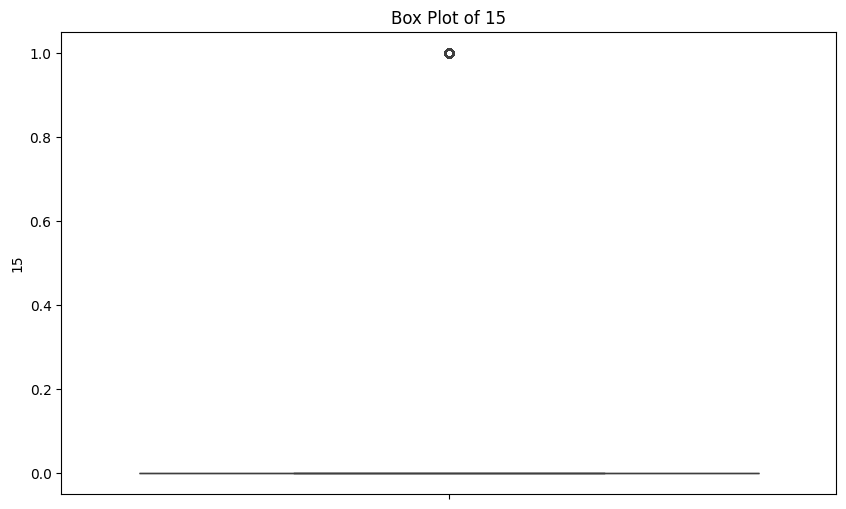

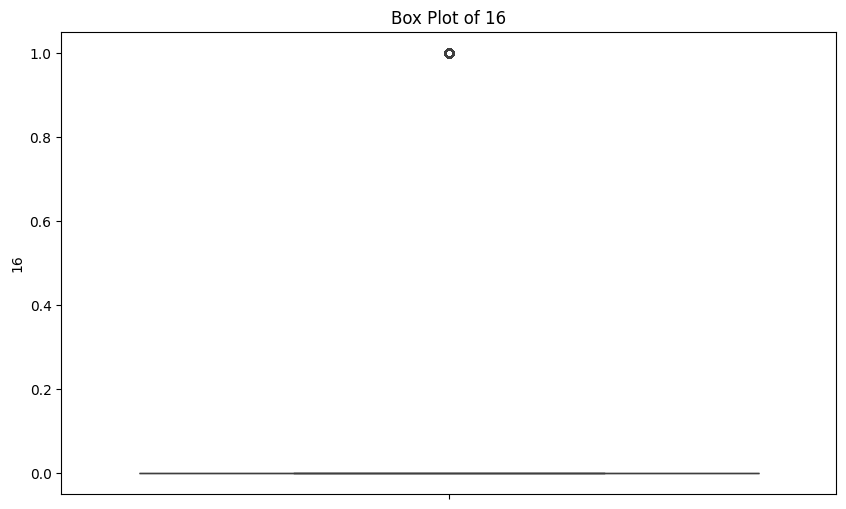

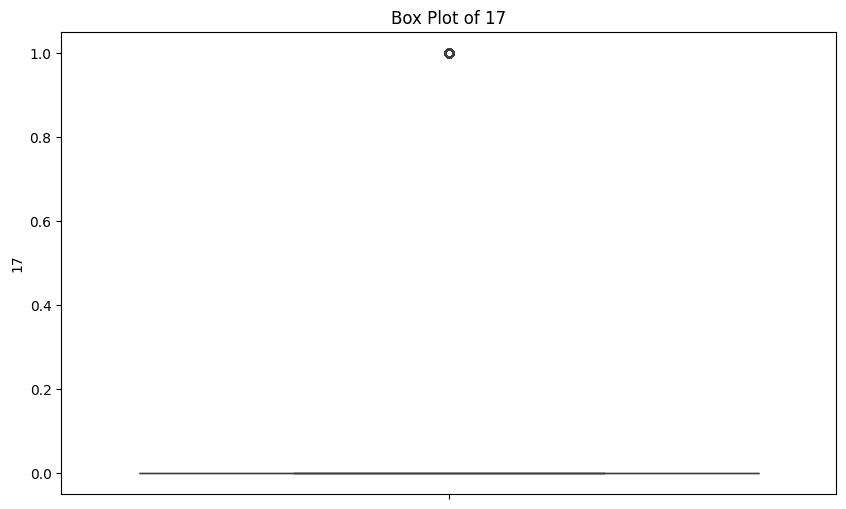

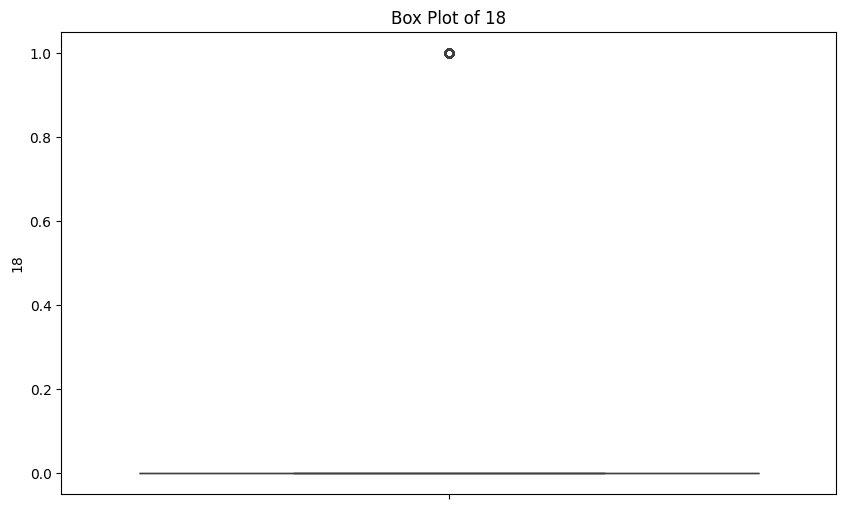

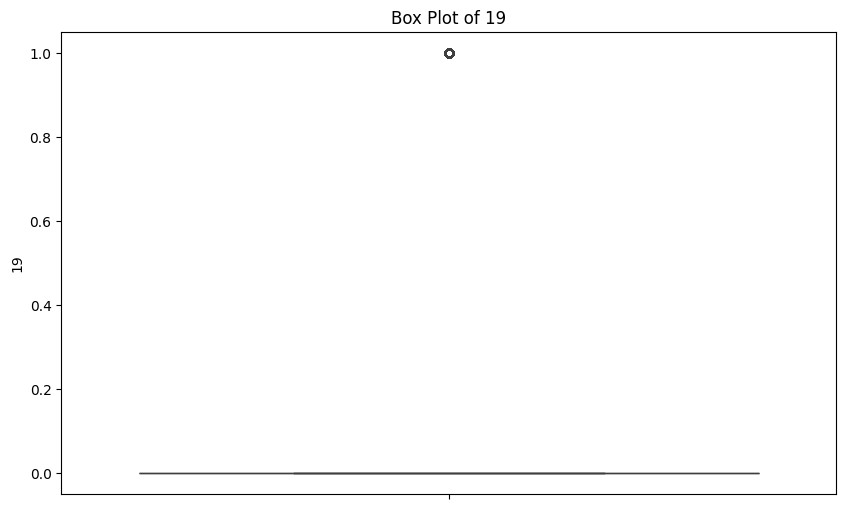

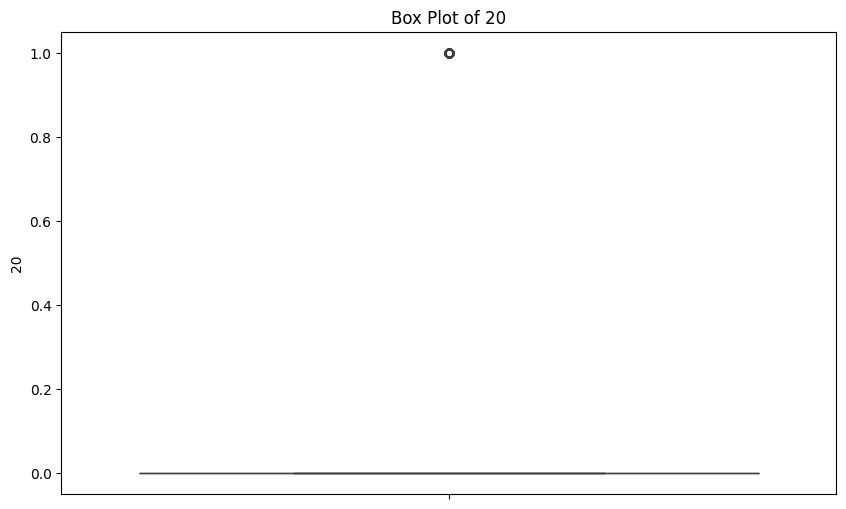

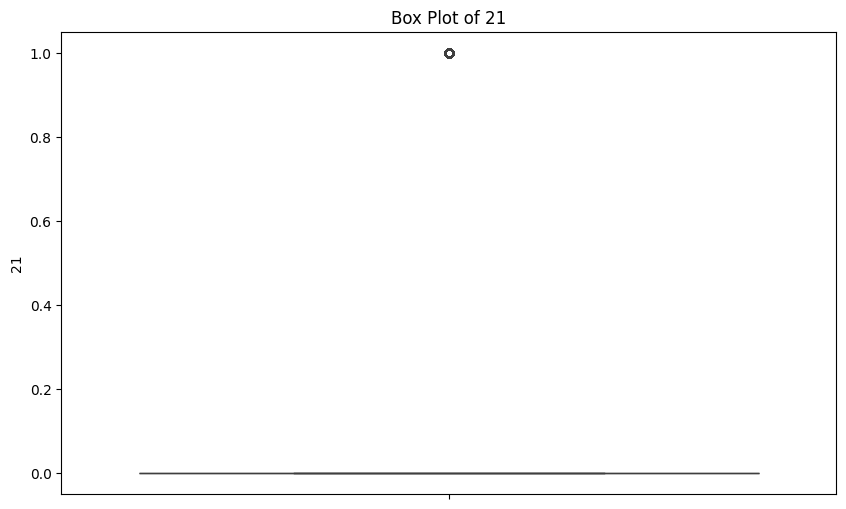

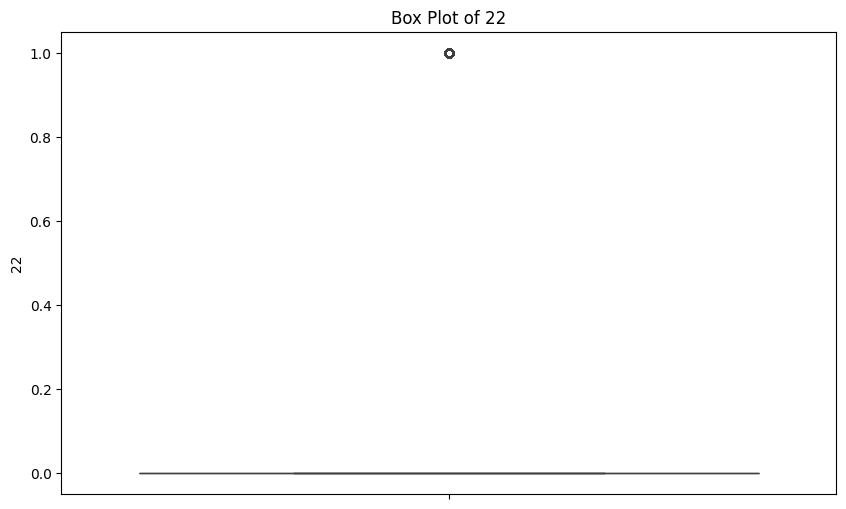

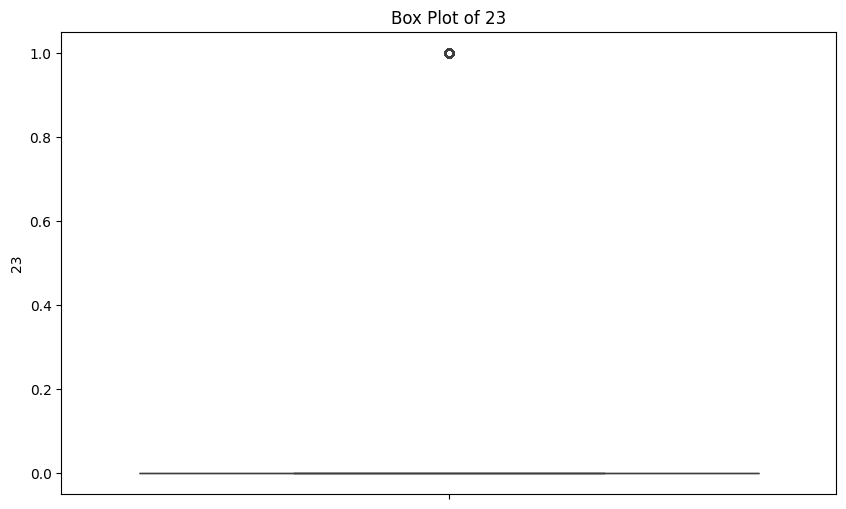

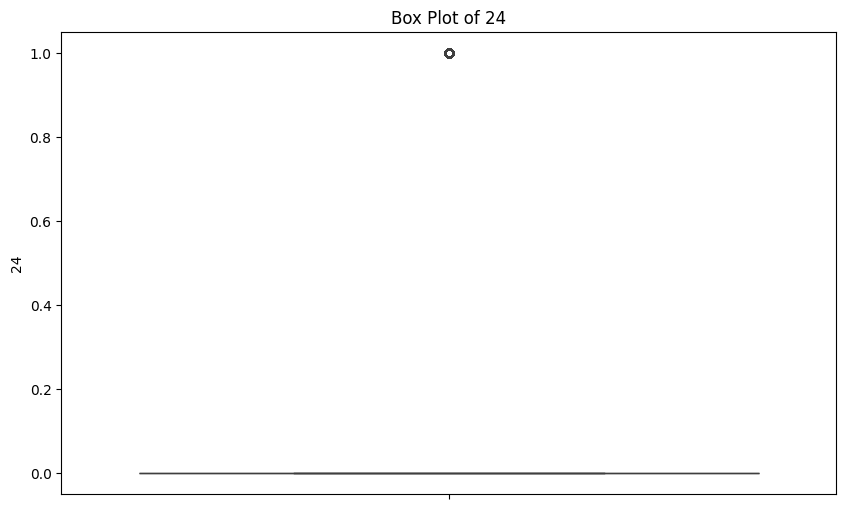

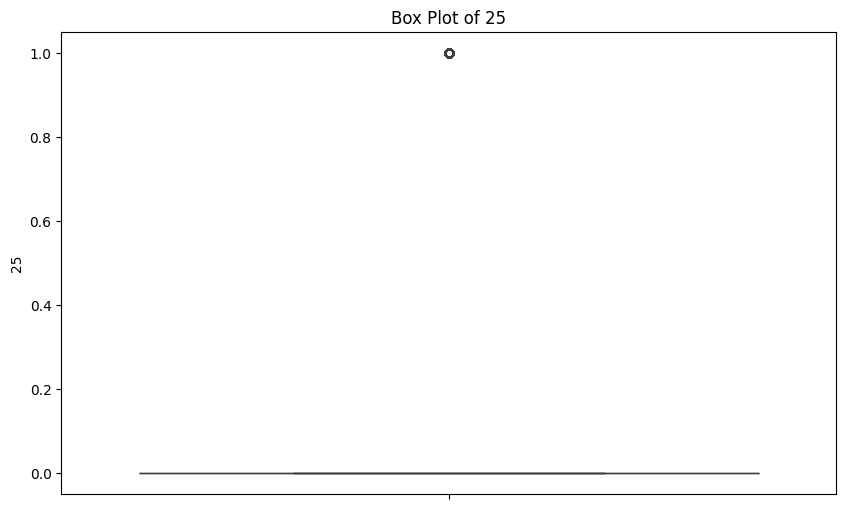

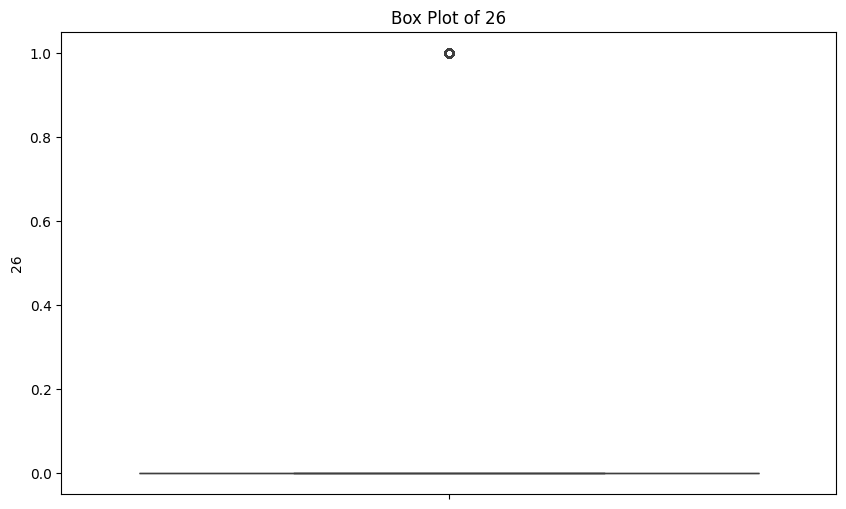

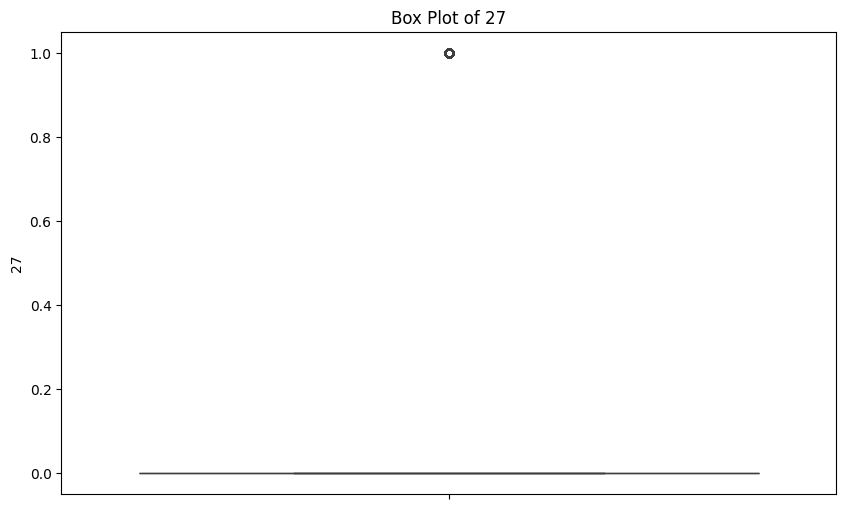

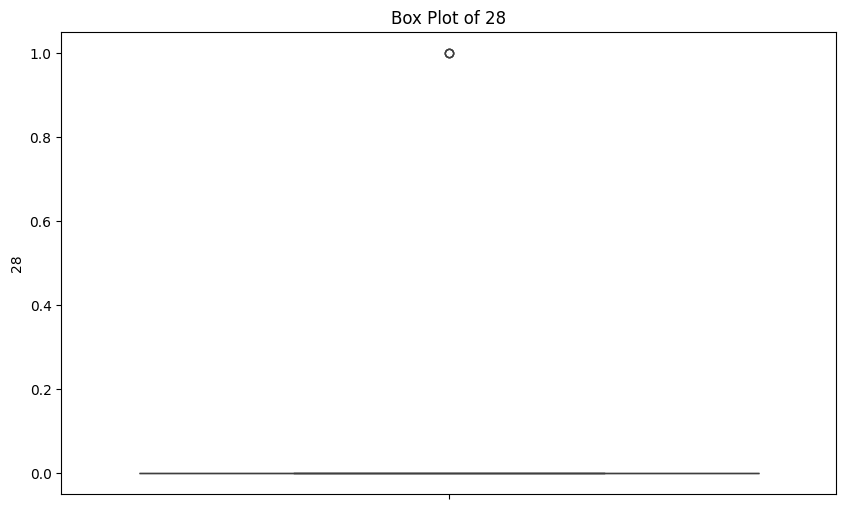

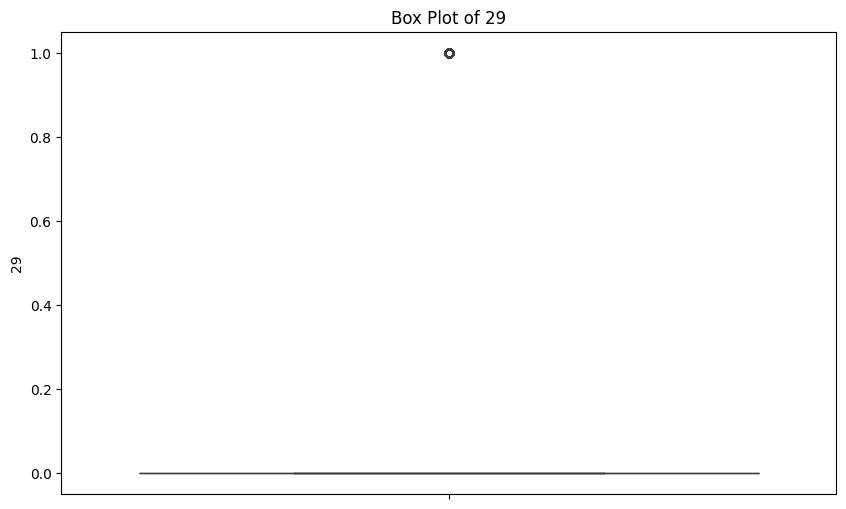

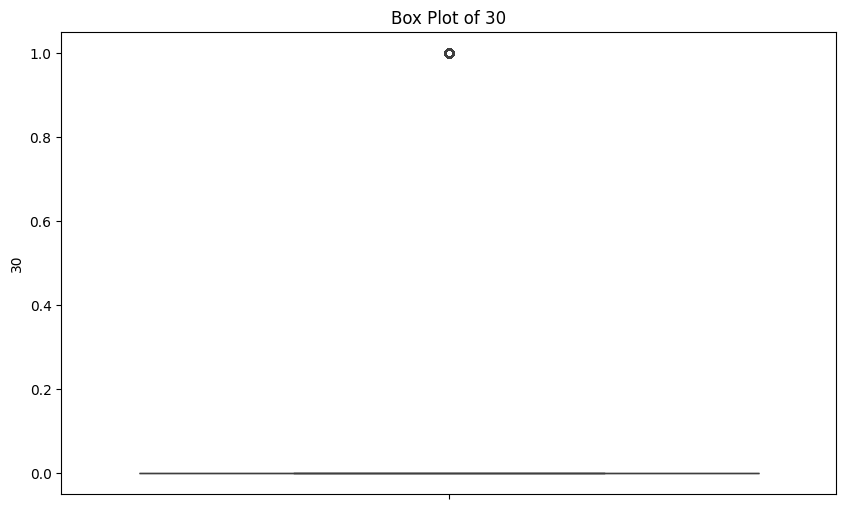

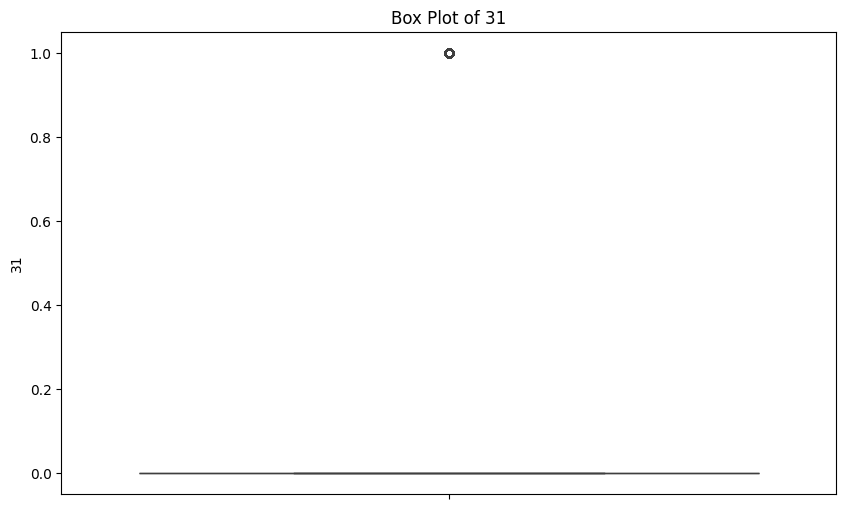

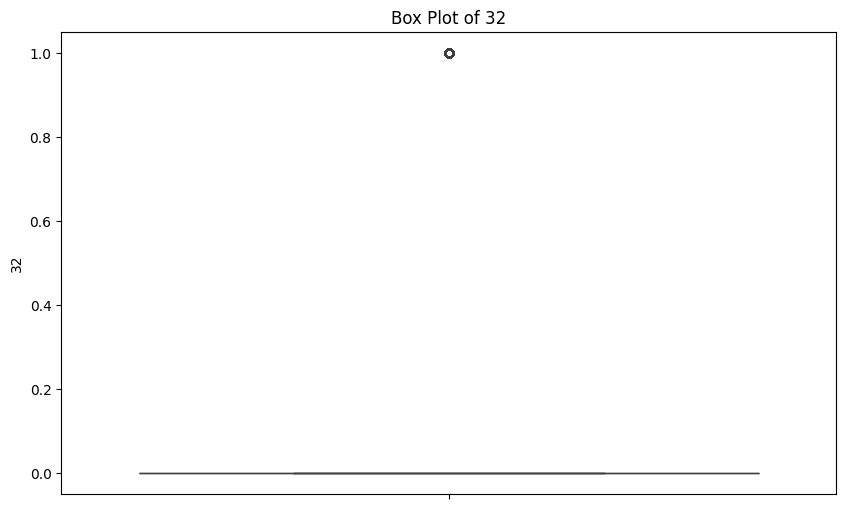

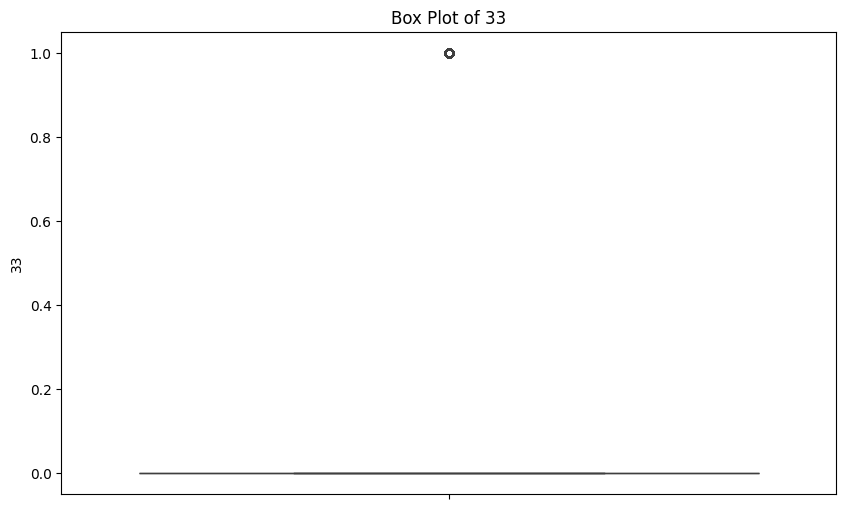

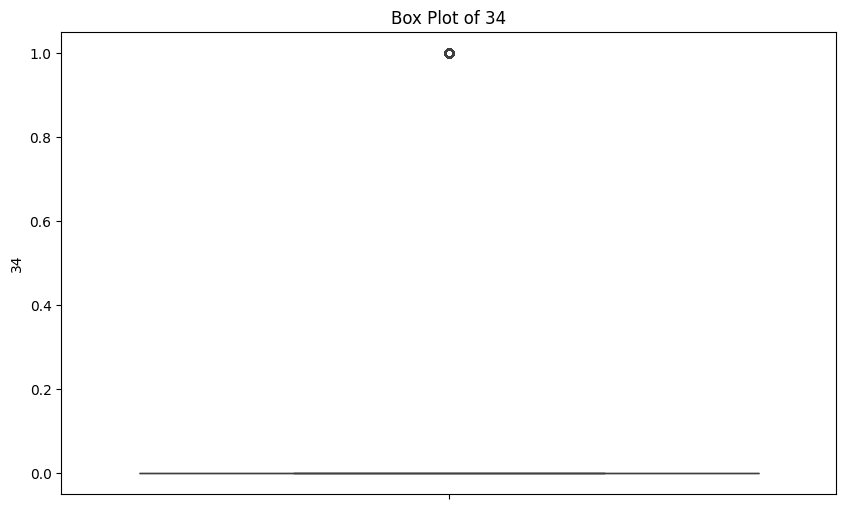

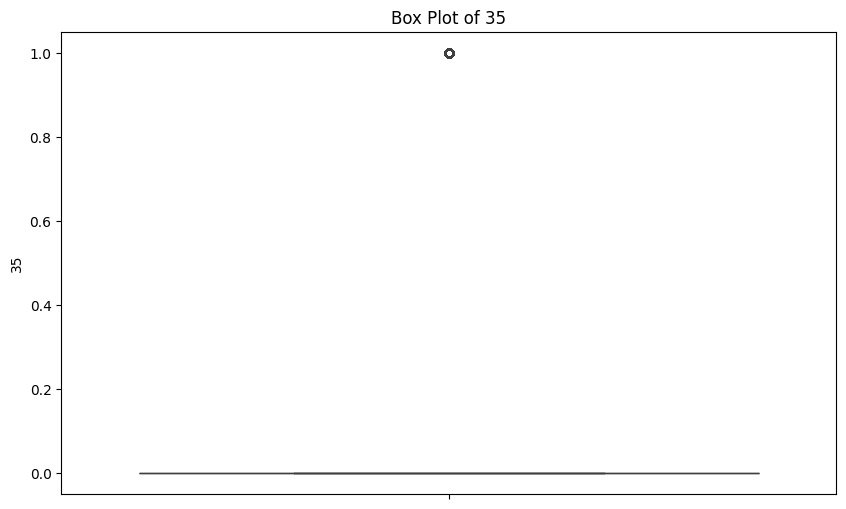

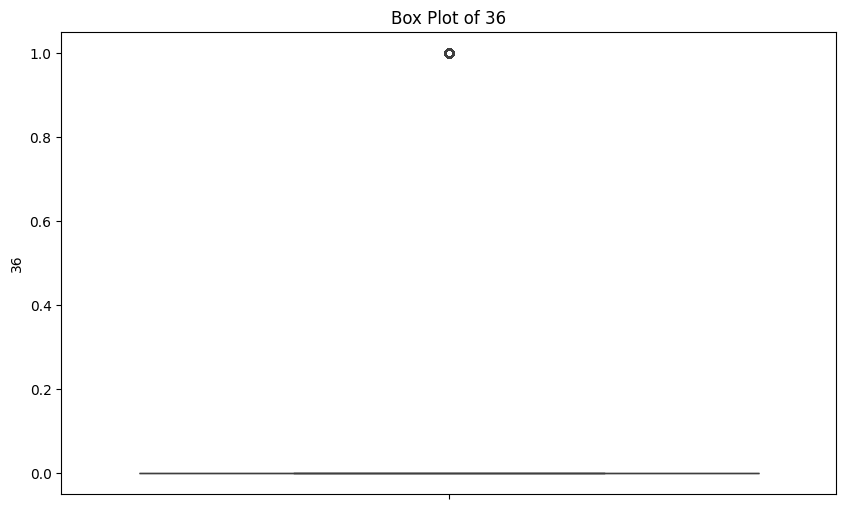

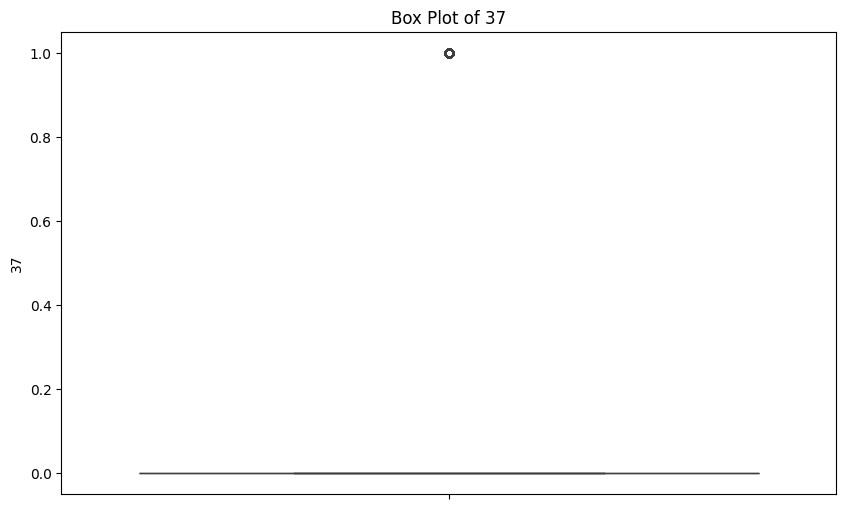

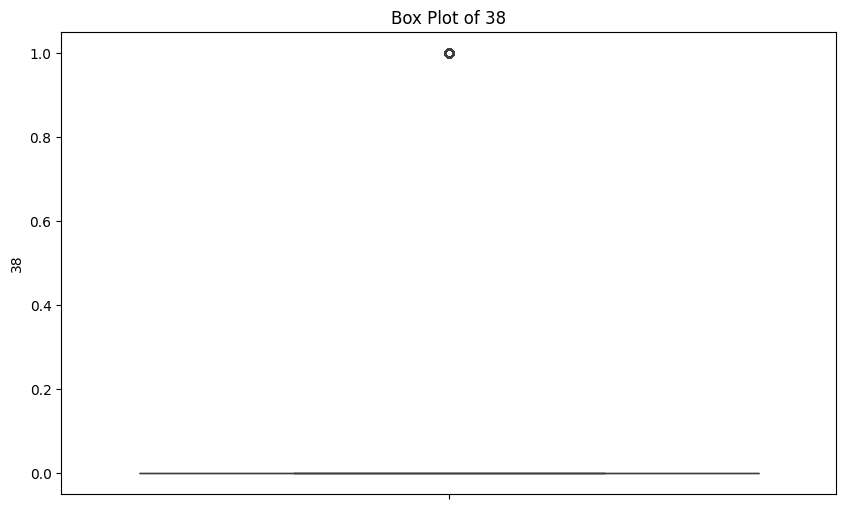

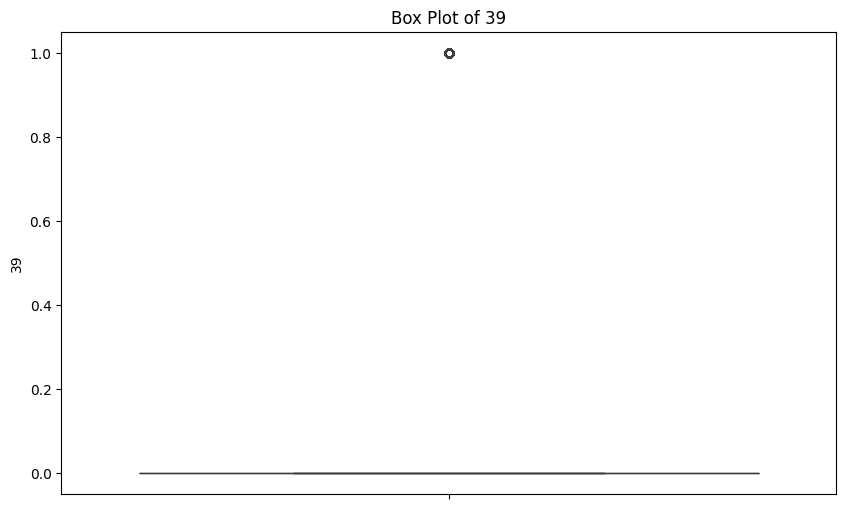

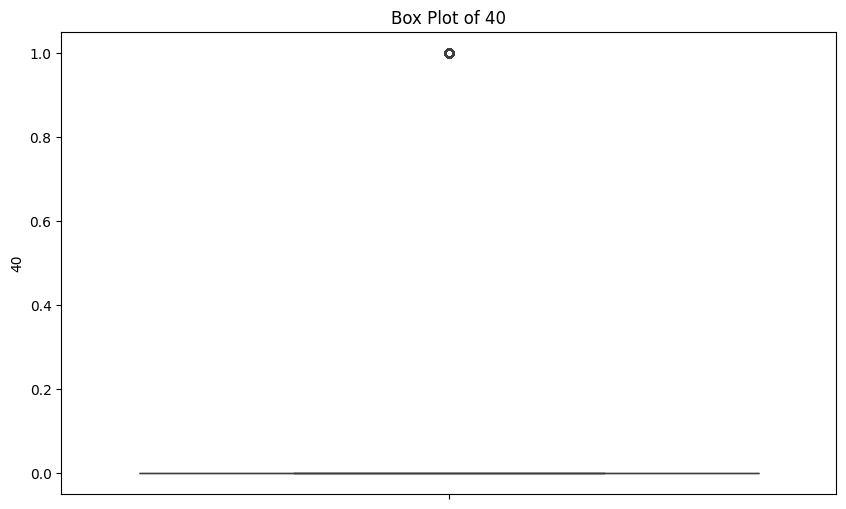

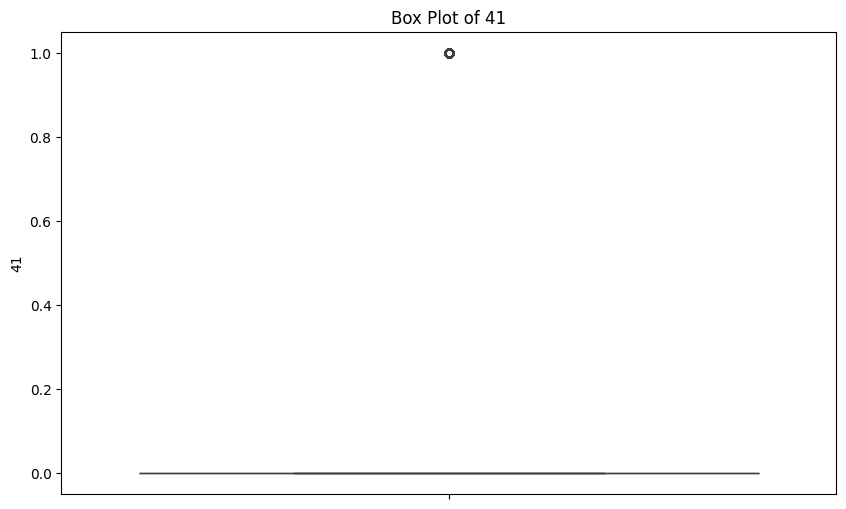

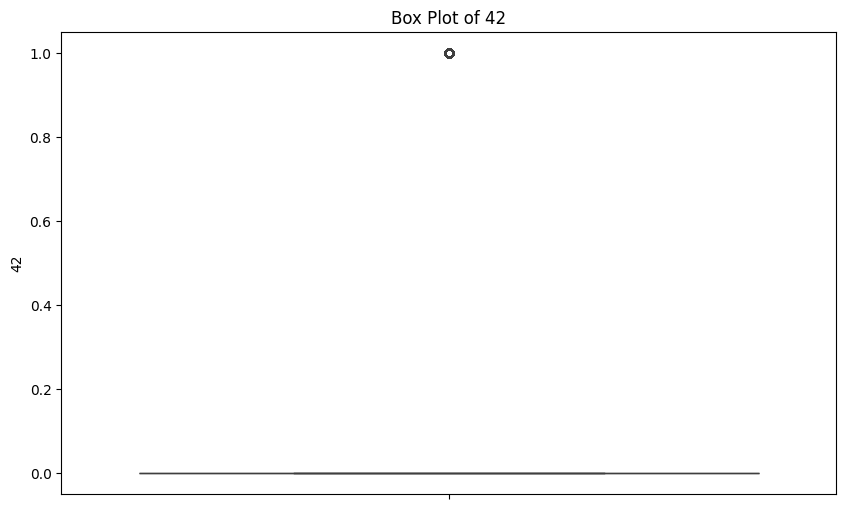

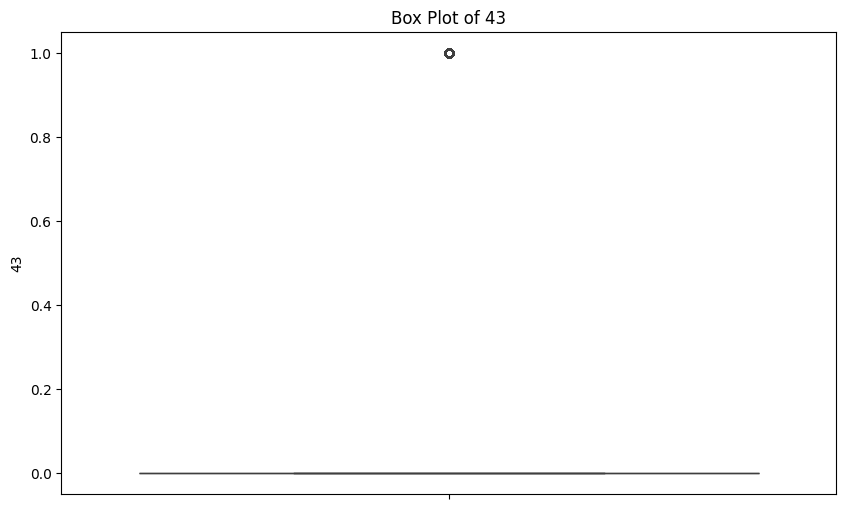

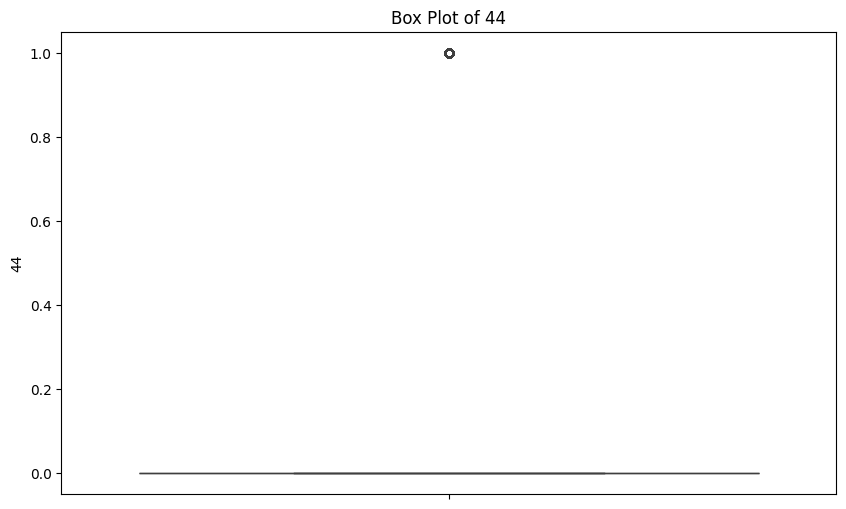

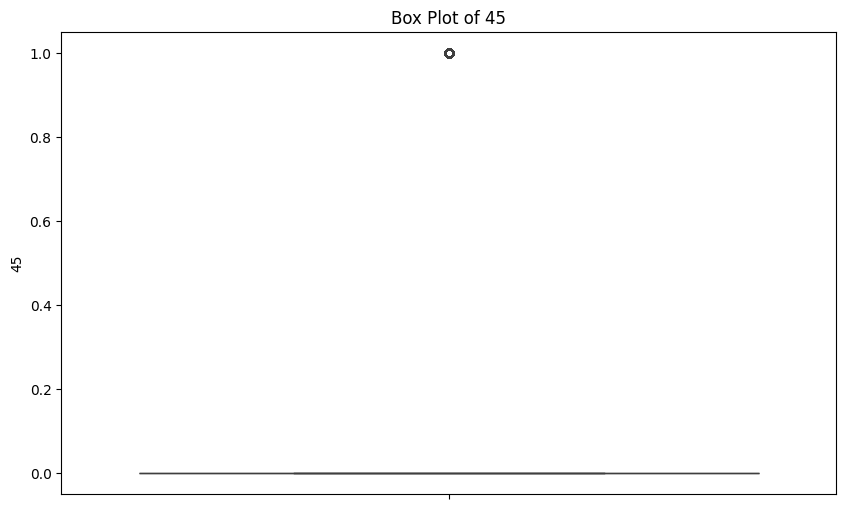

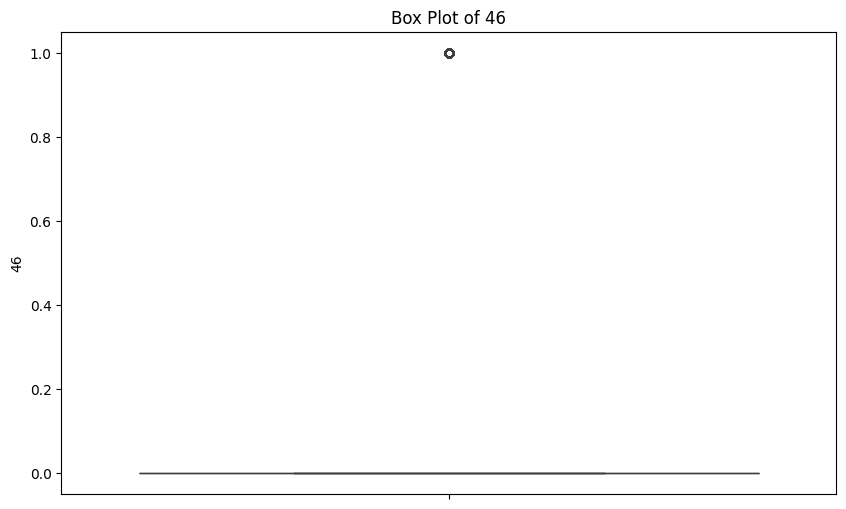

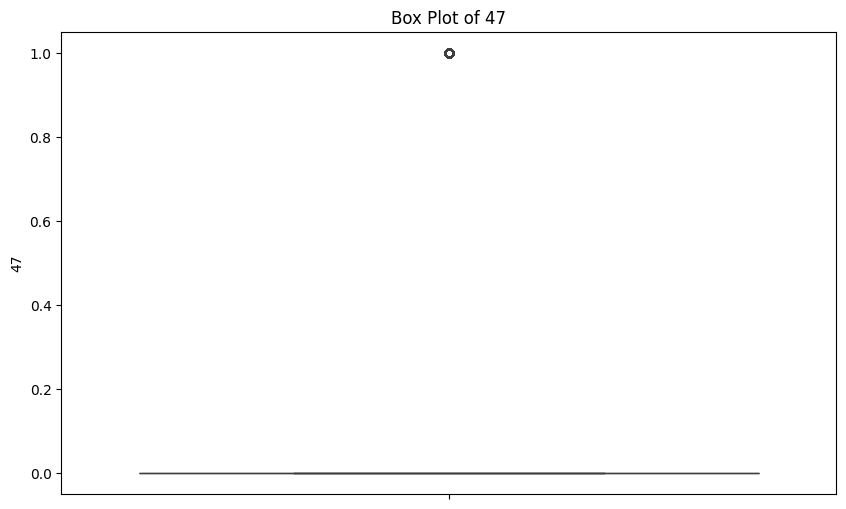

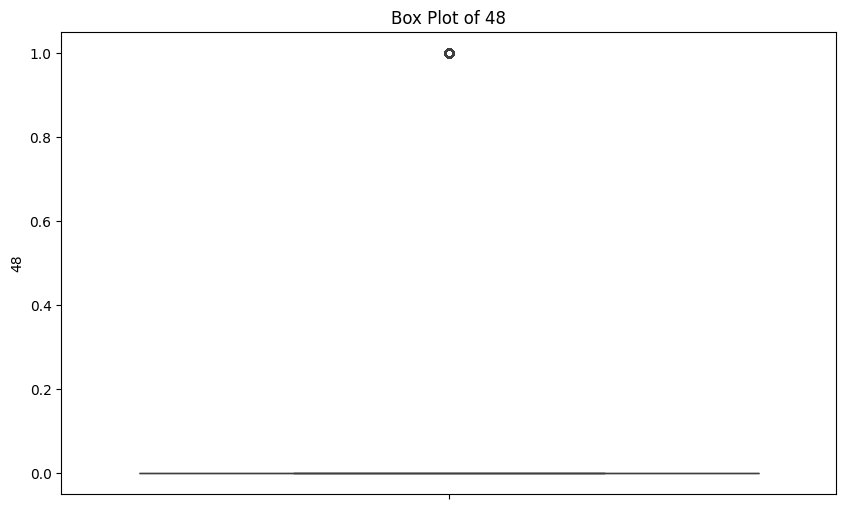

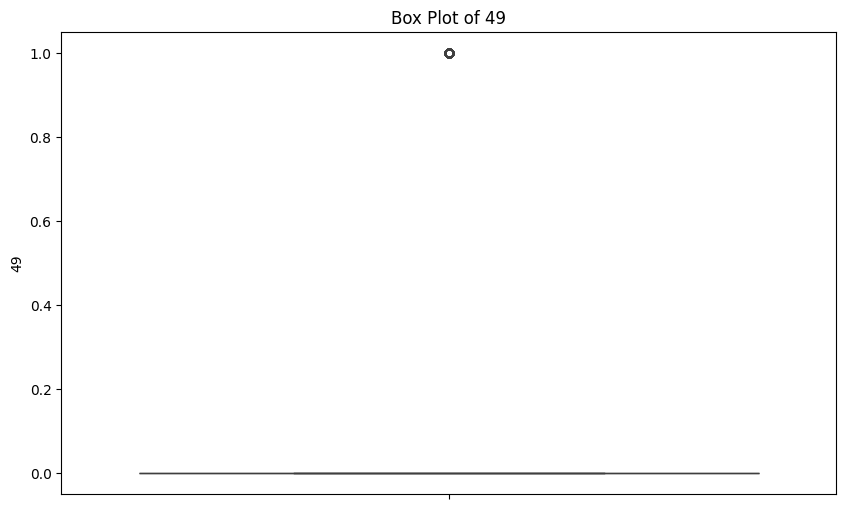

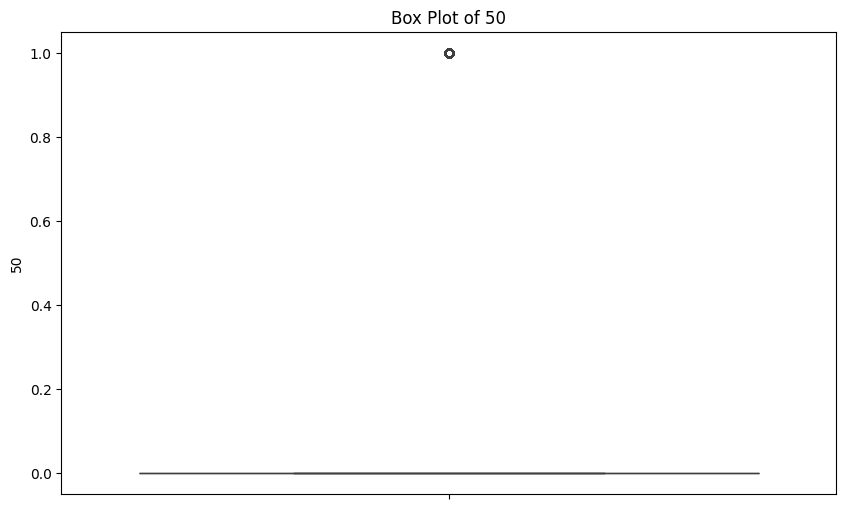

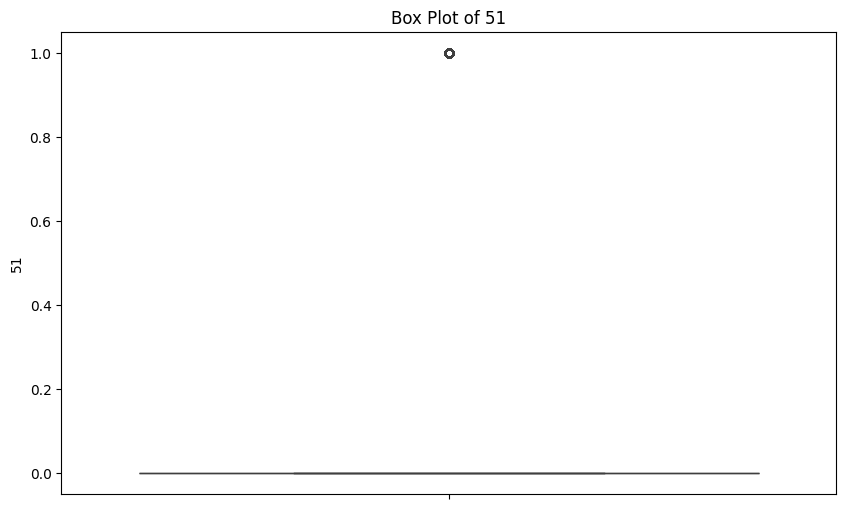

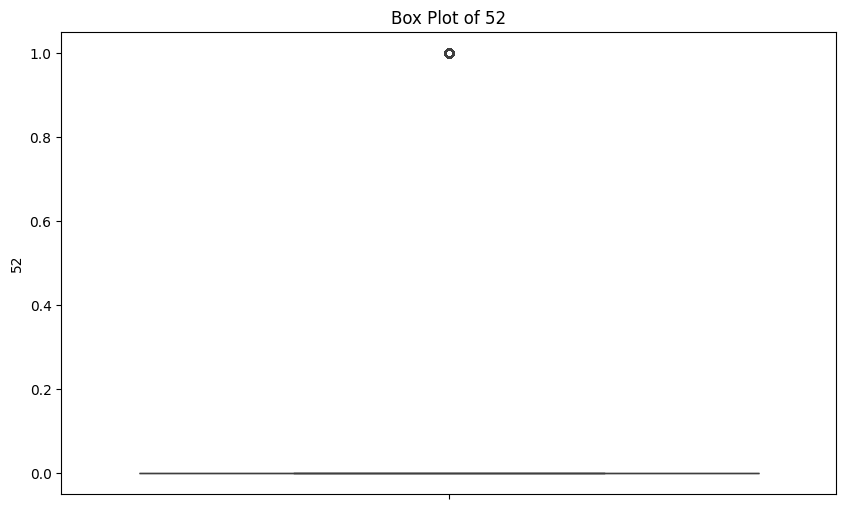

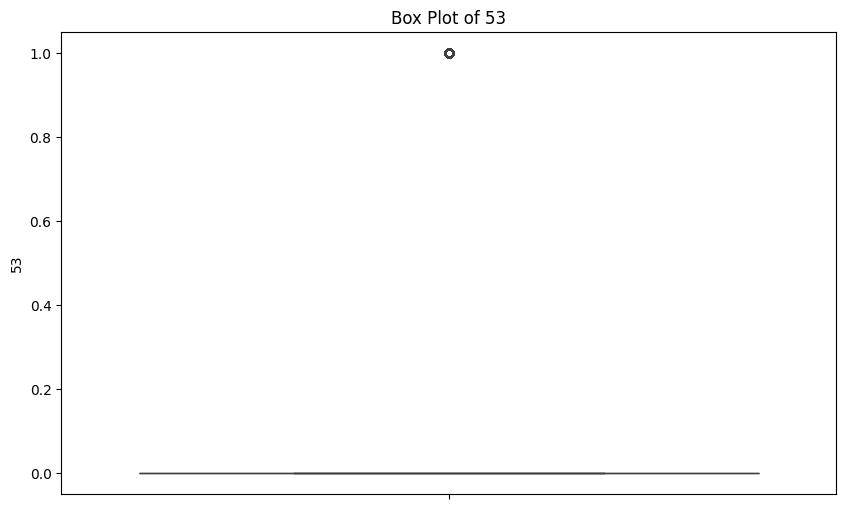

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through all feature columns and create box plots to visualize outliers
for feature in feature_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(y=data[feature])
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)
    plt.show()

### Handling Outliers using IQR Capping

We will cap outliers using the Interquartile Range (IQR) method.

In [16]:
# Create a copy of the dataframe to store capped data
data_capped = data.copy()

for feature in feature_cols:
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the outliers
    data_capped[feature] = np.where(data_capped[feature] < lower_bound, lower_bound, data_capped[feature])
    data_capped[feature] = np.where(data_capped[feature] > upper_bound, upper_bound, data_capped[feature])

print("Outliers capped for all features using IQR method. Displaying head of the new dataframe:")
display(data_capped.head())

Outliers capped for all features using IQR method. Displaying head of the new dataframe:


,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,4839.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,4839.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,4839.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,4839.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,4839.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


**Now, let's re-plot the box plots for a few features to see the effect of capping.**

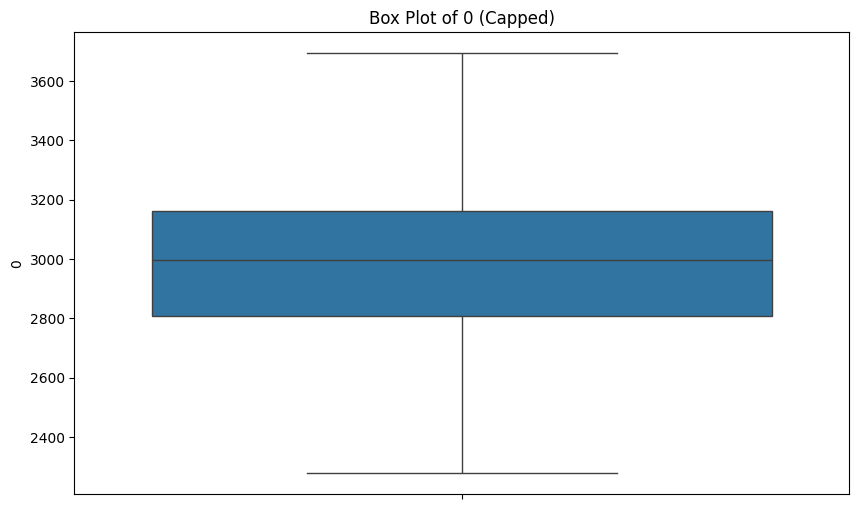

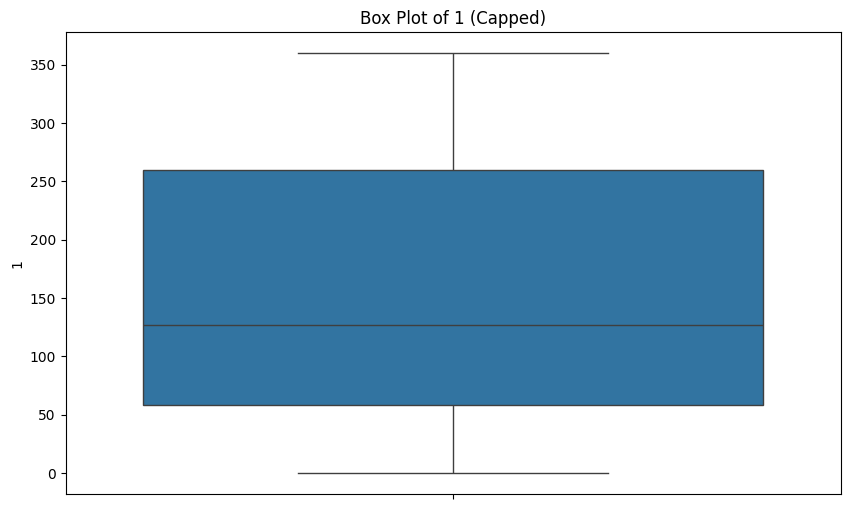

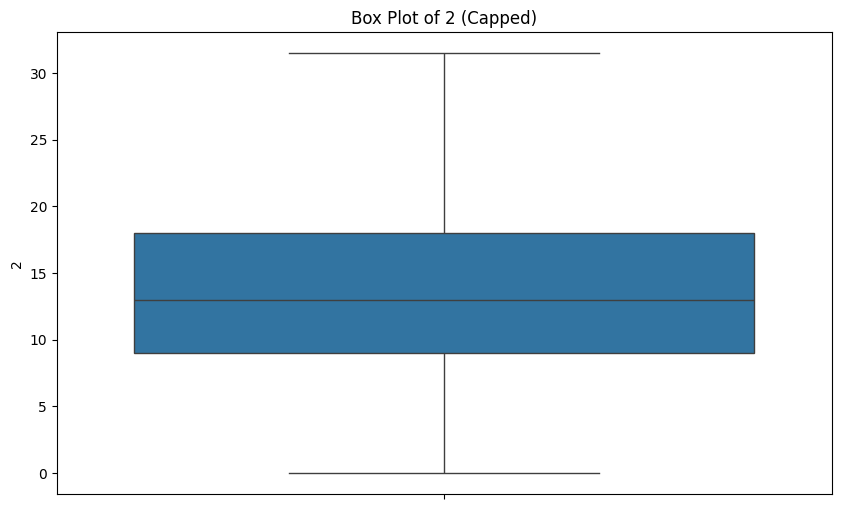

In [17]:
# Re-plot box plots for the first 3 features with capped data
for feature in feature_cols[:3]:
    plt.figure(figsize=(10, 6))
    sns.boxplot(y=data_capped[feature])
    plt.title(f'Box Plot of {feature} (Capped)')
    plt.ylabel(feature)
    plt.show()

**Histogram to check the skewness of the dat**a

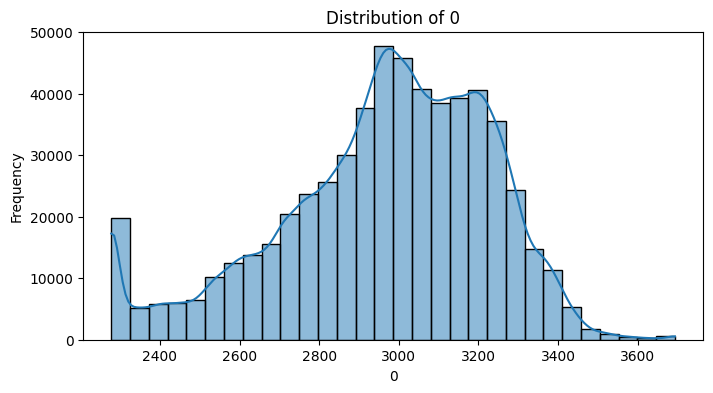

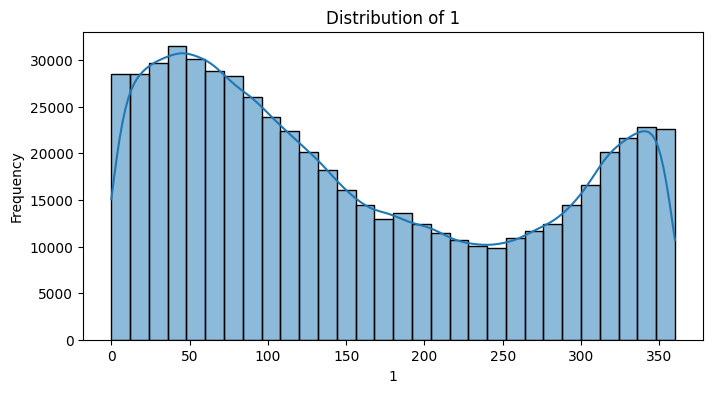

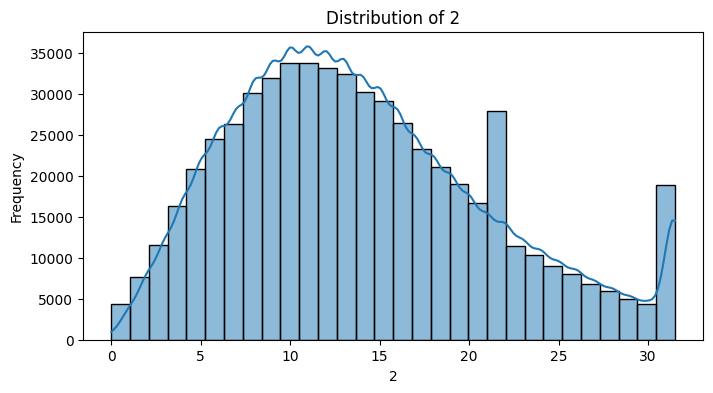

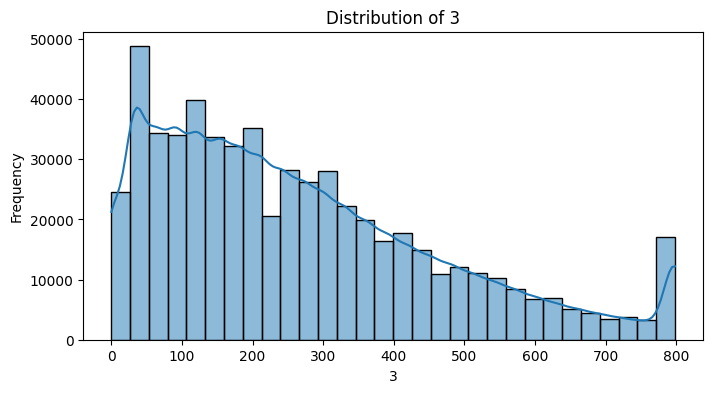

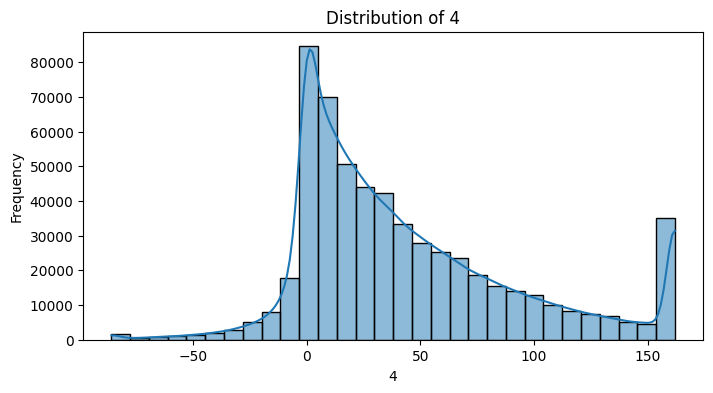

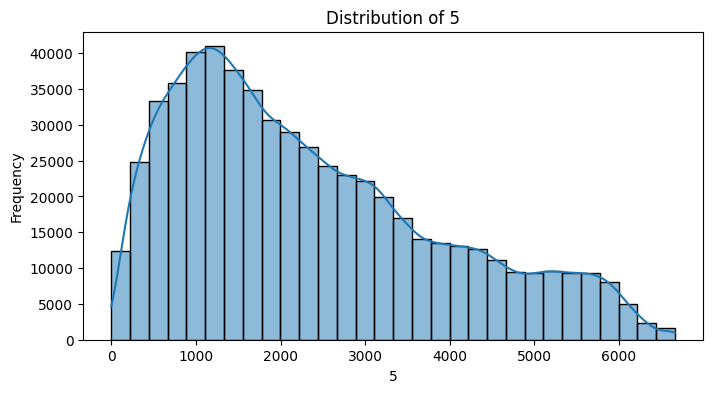

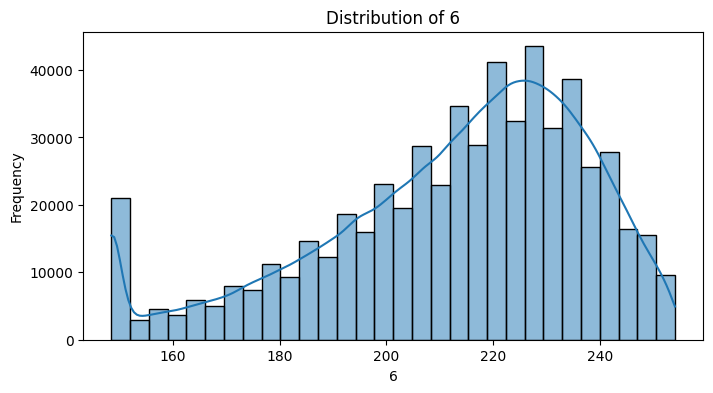

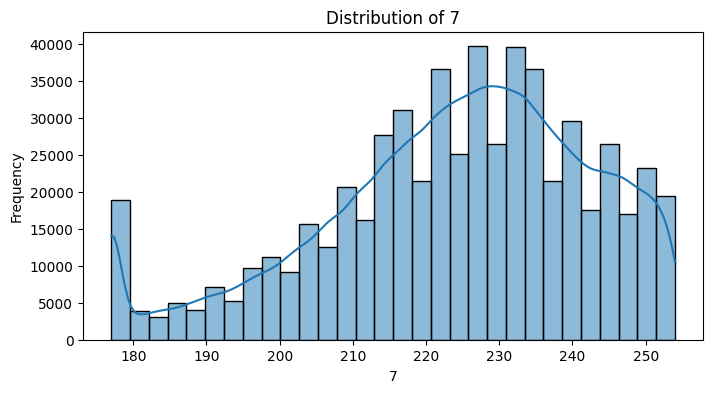

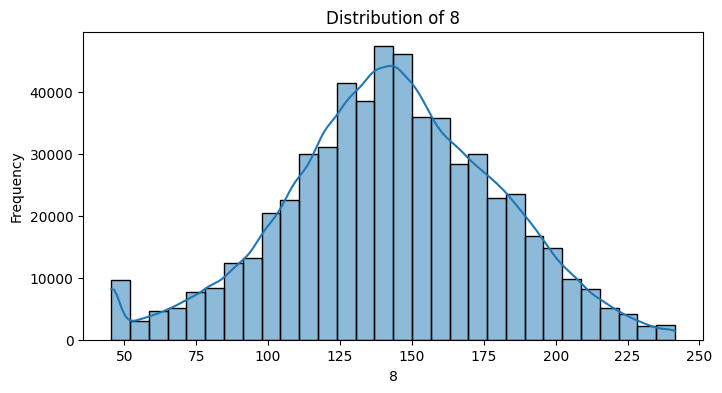

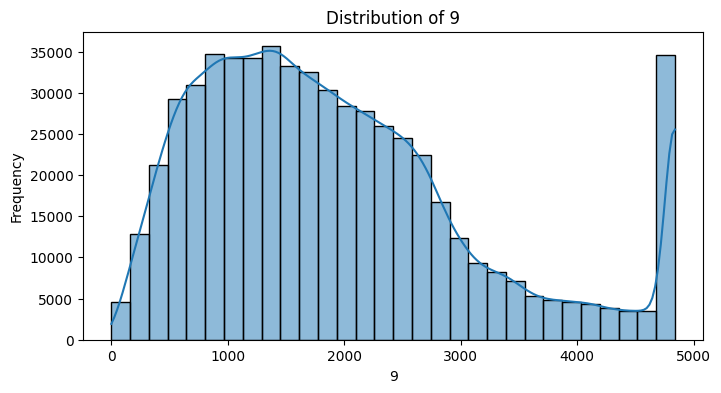

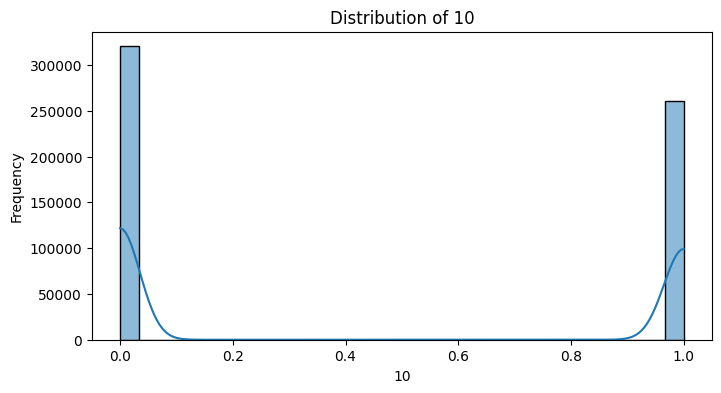

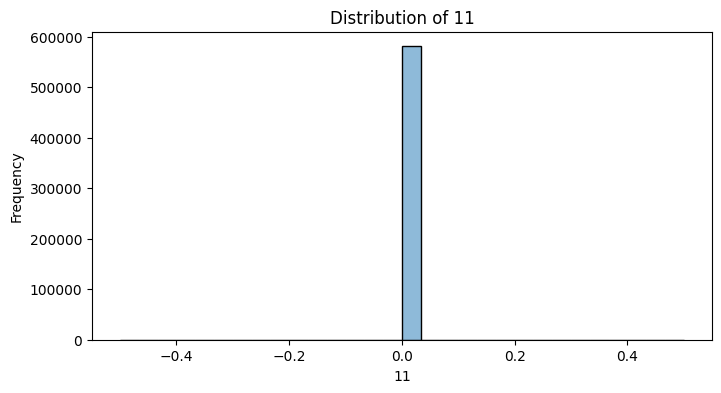

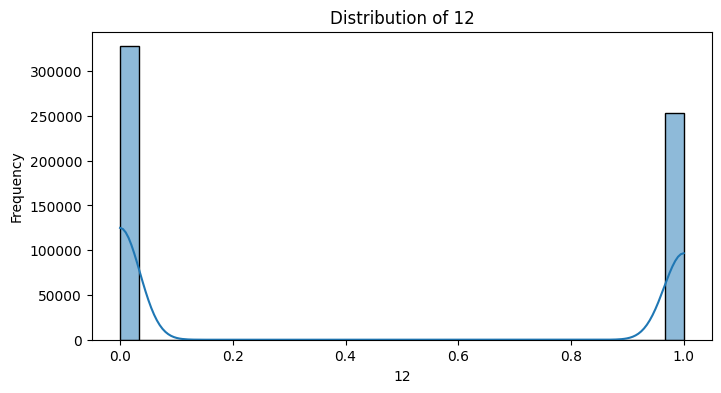

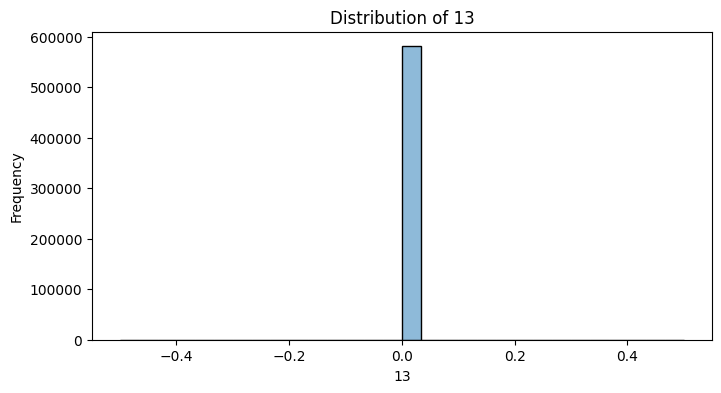

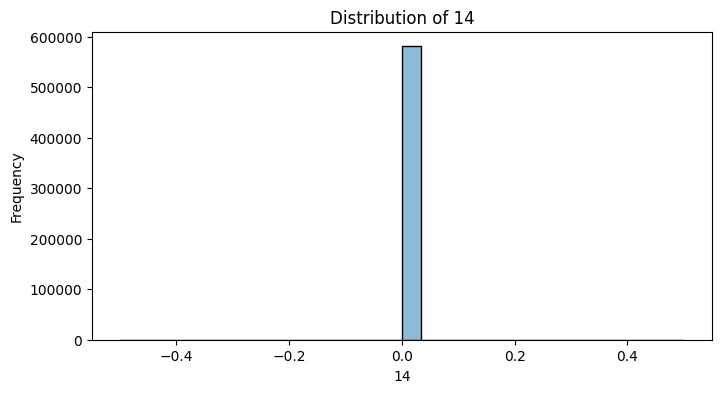

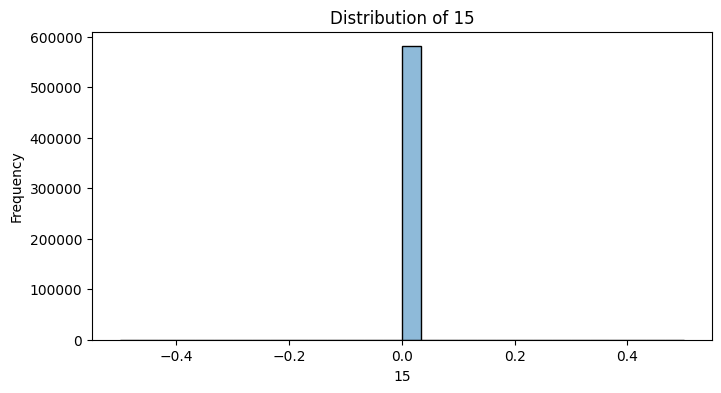

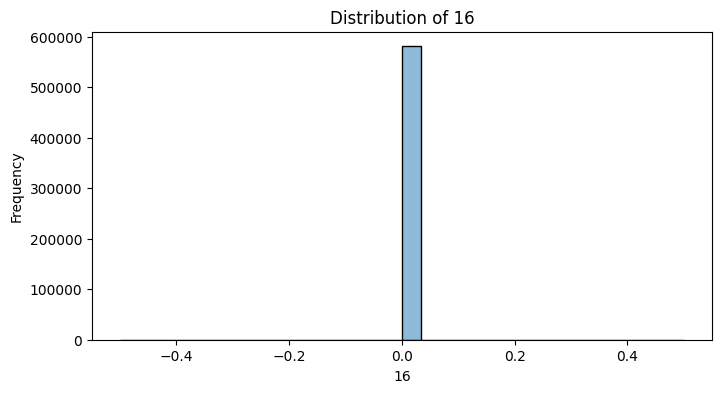

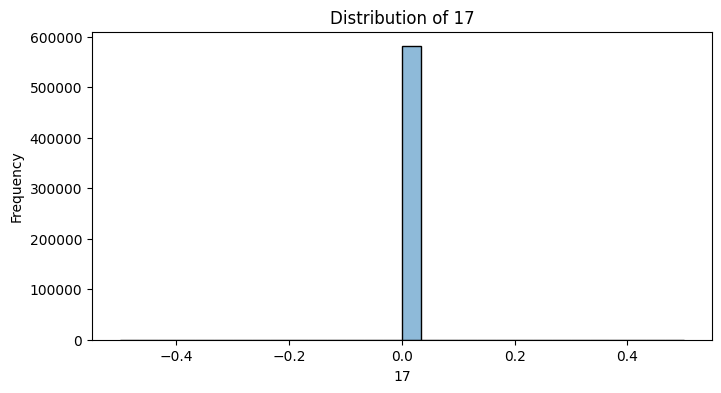

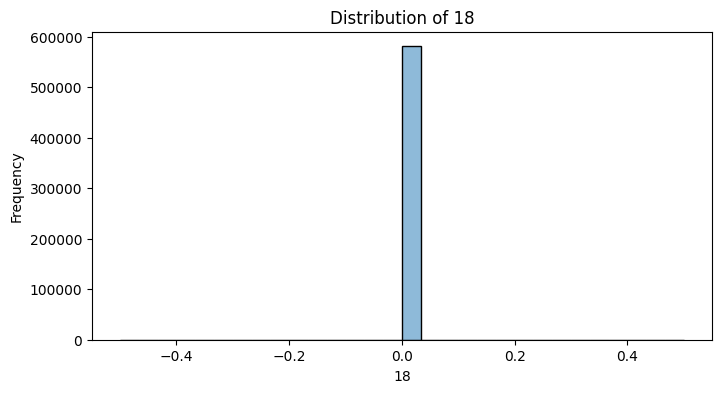

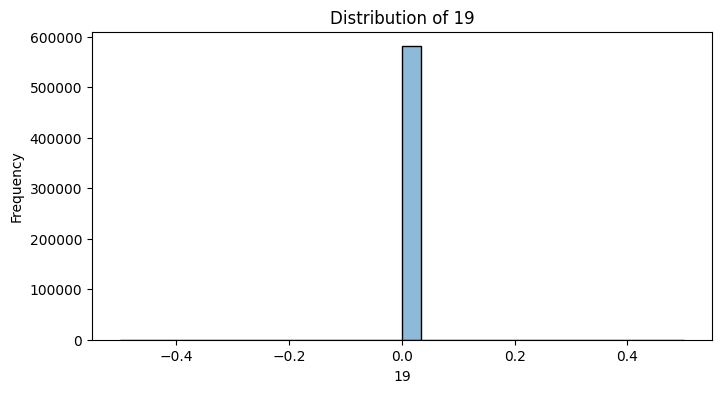

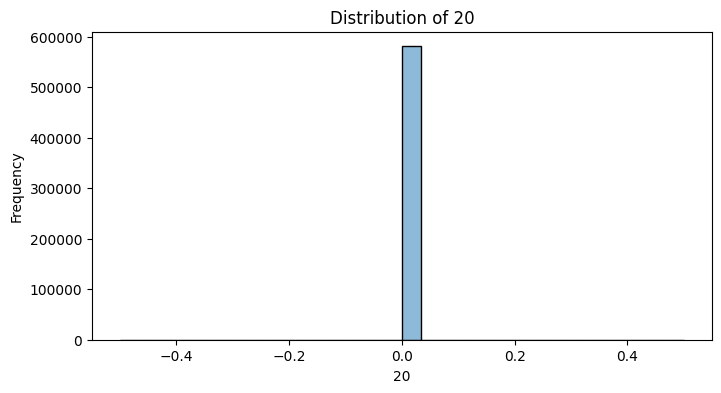

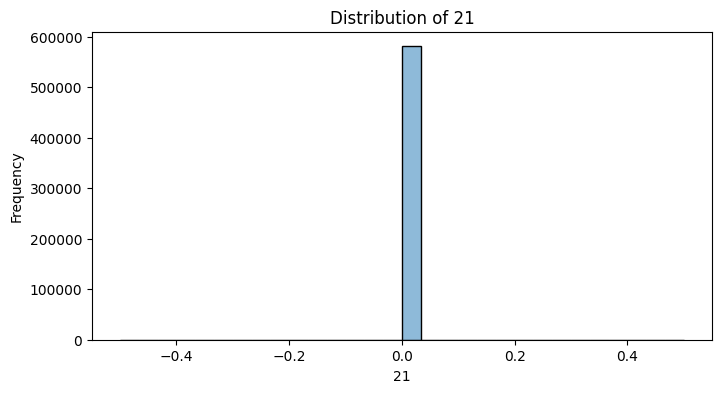

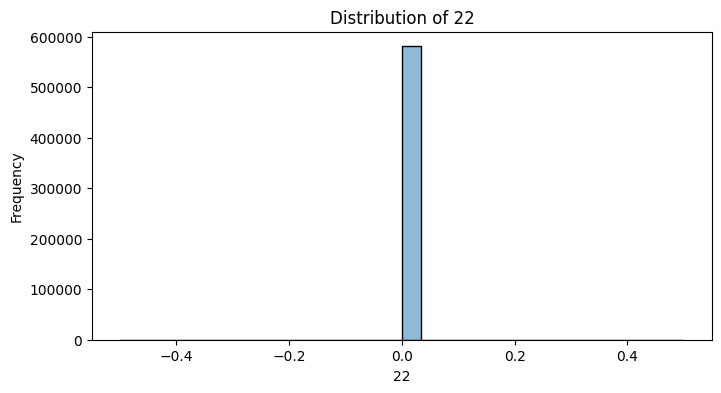

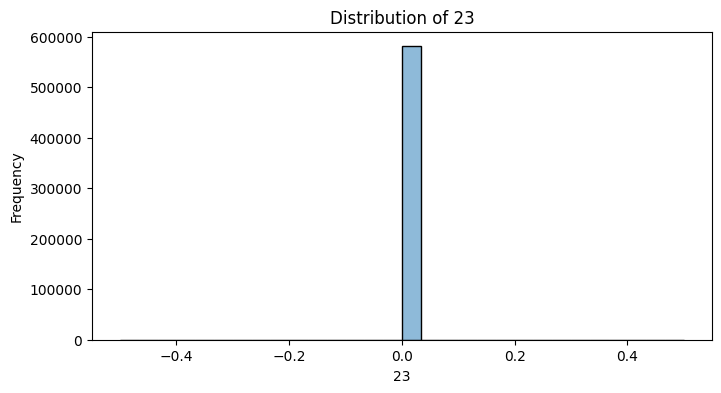

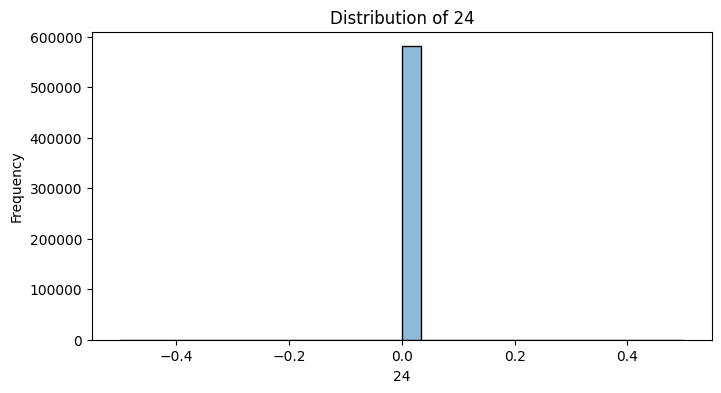

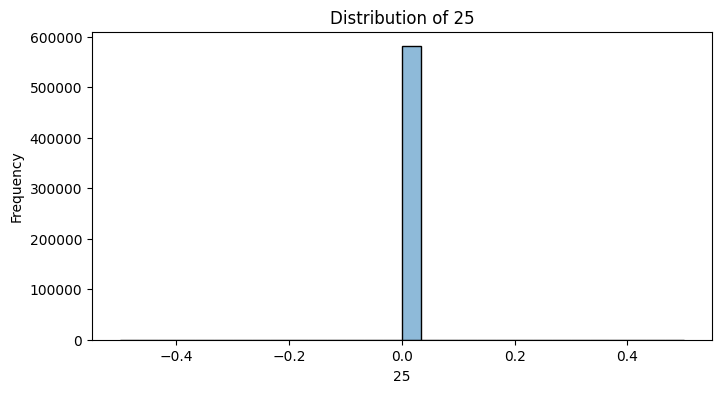

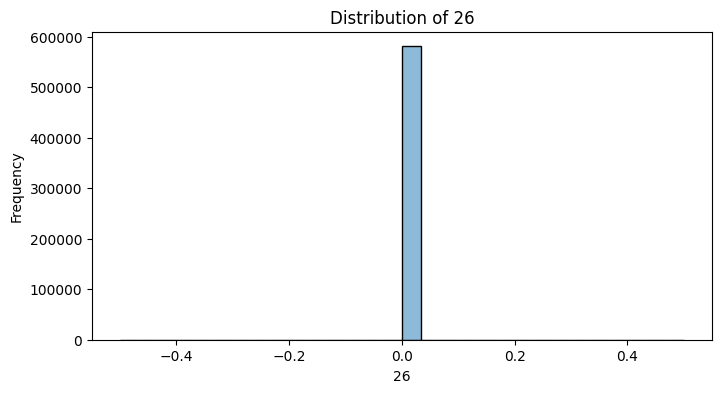

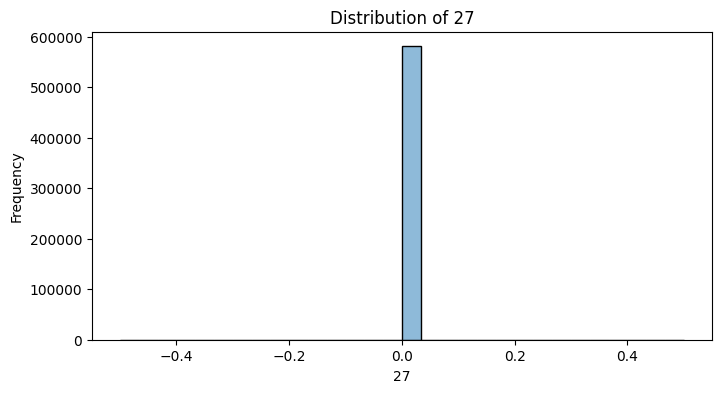

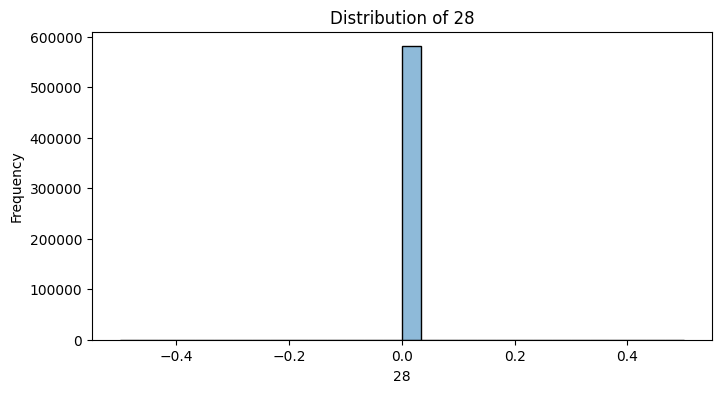

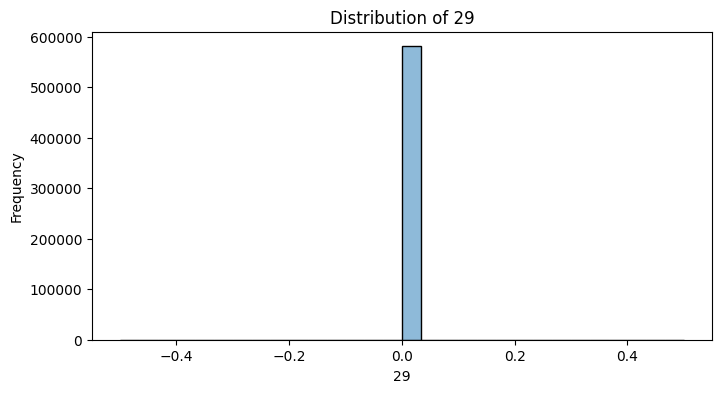

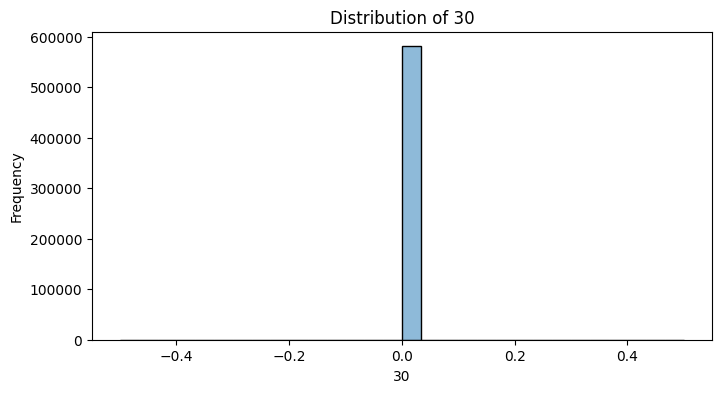

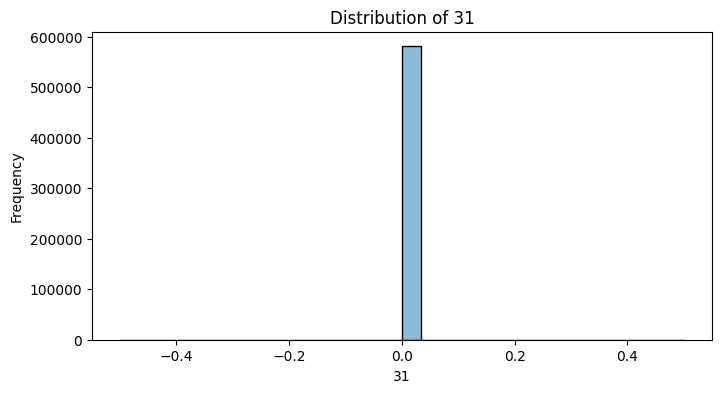

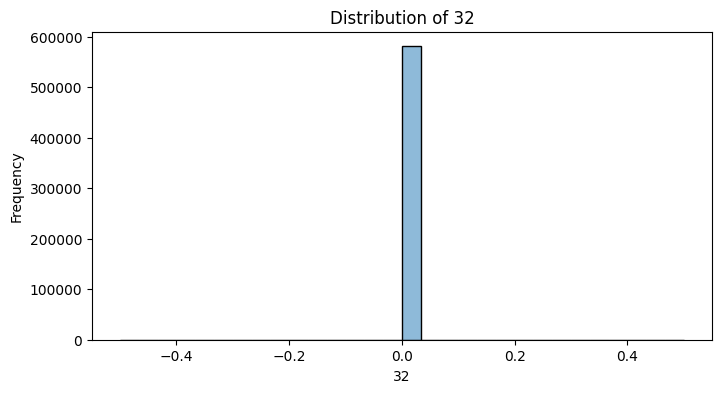

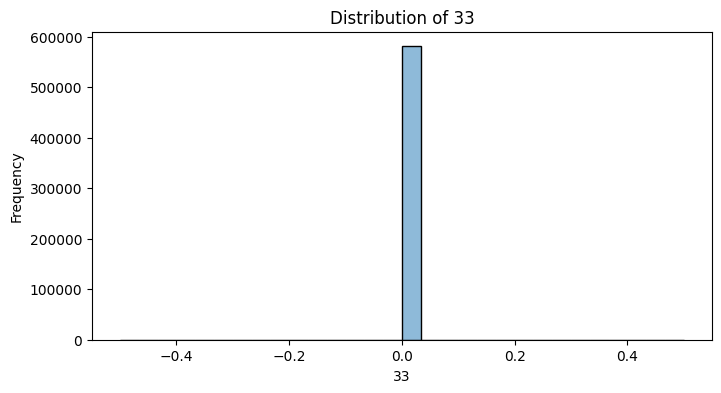

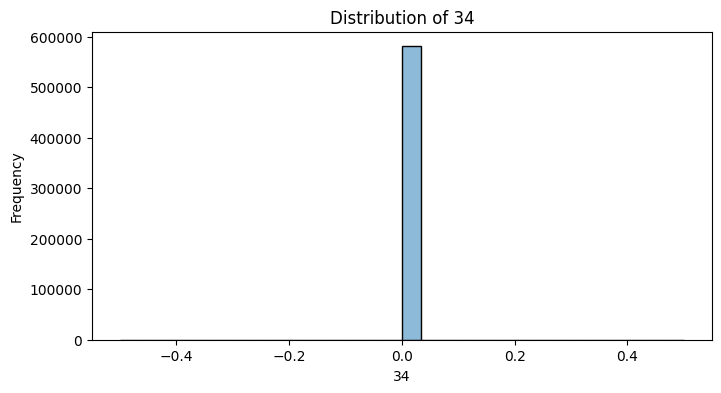

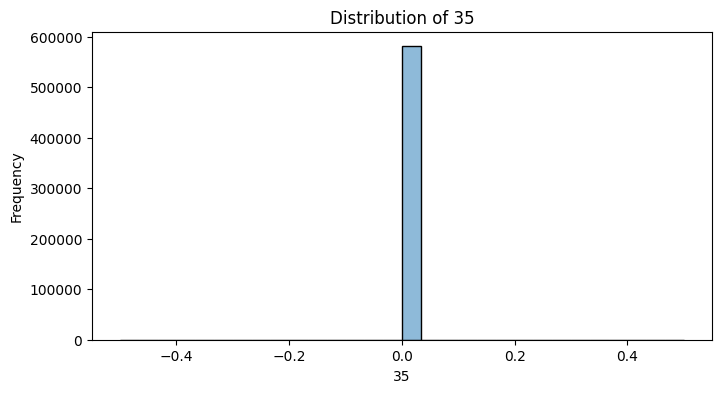

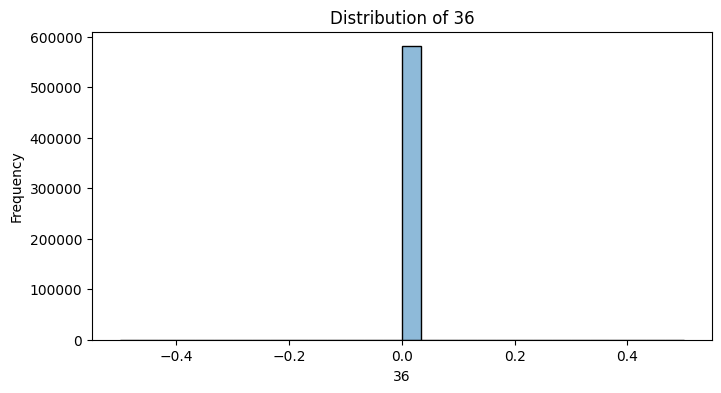

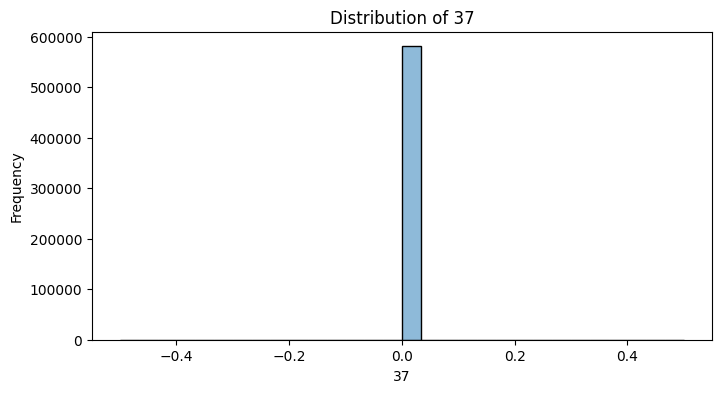

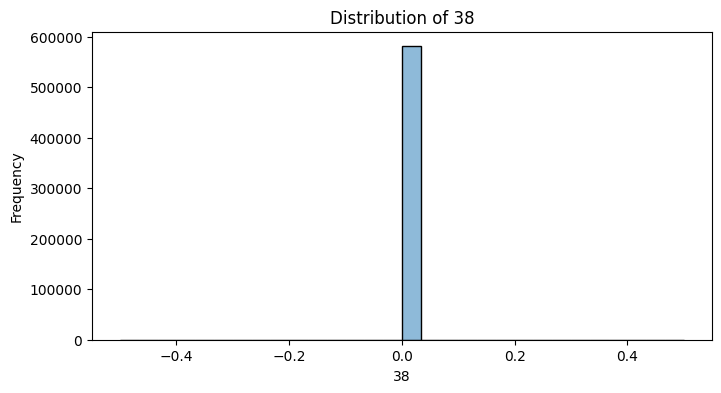

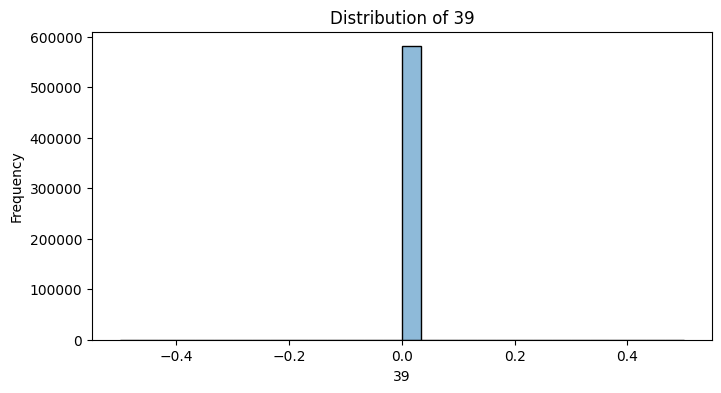

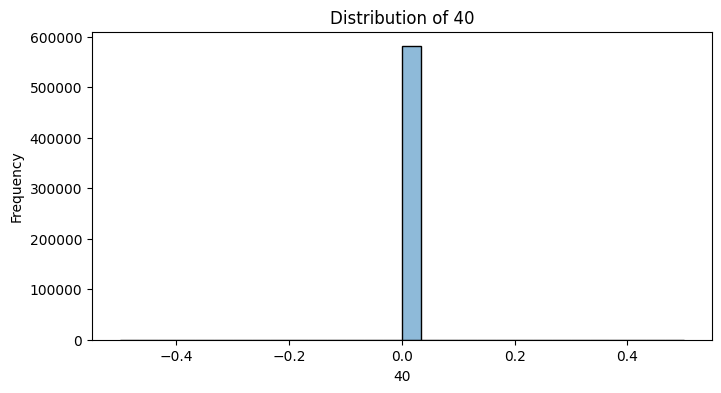

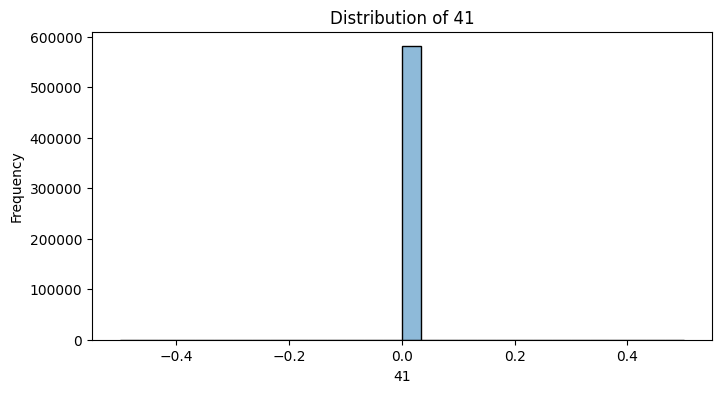

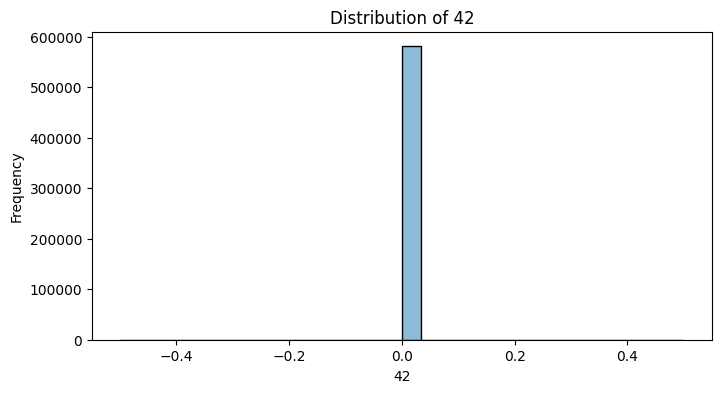

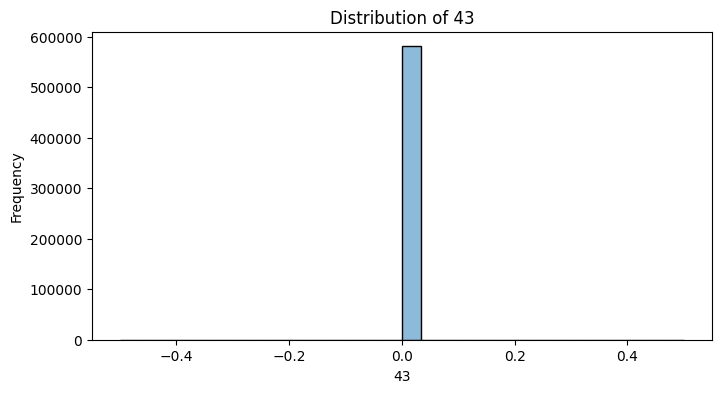

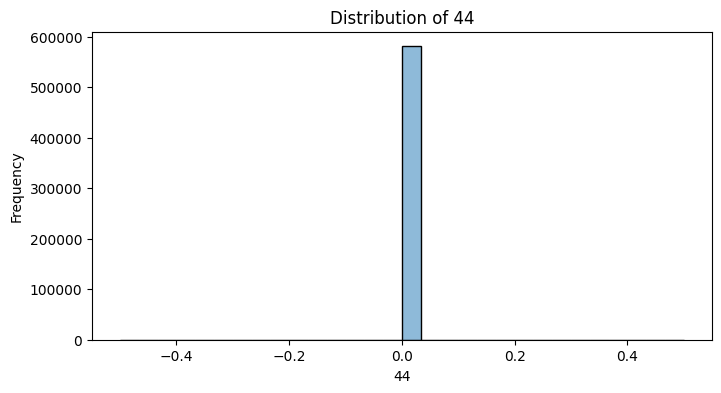

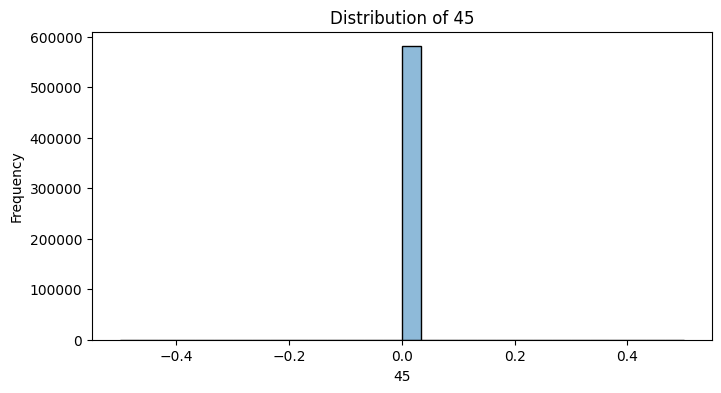

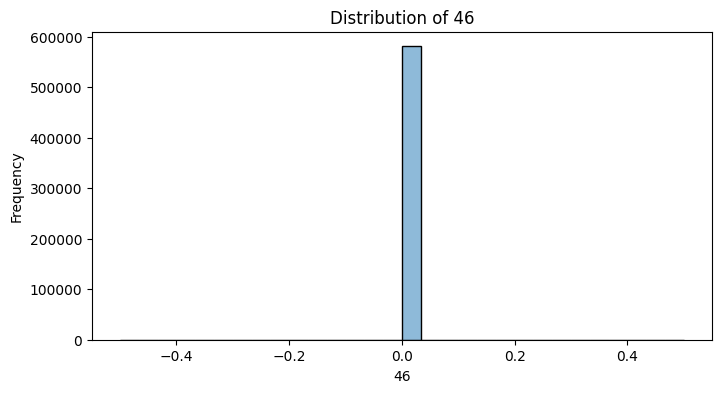

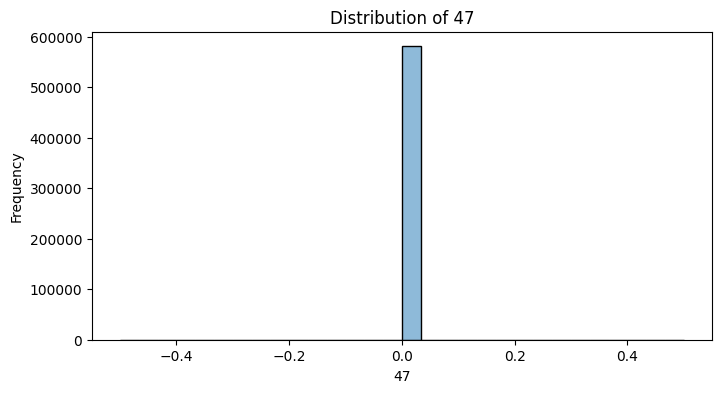

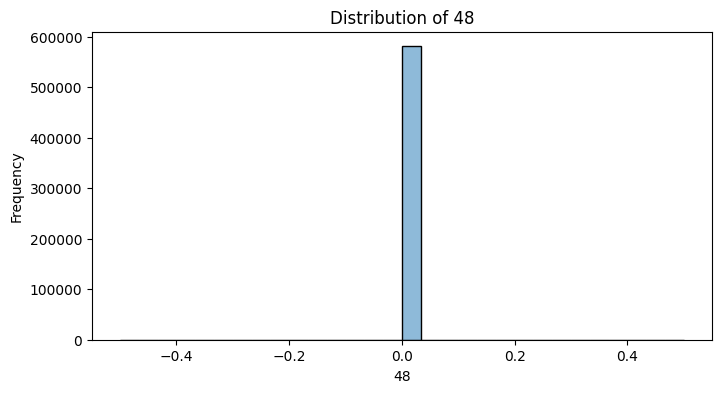

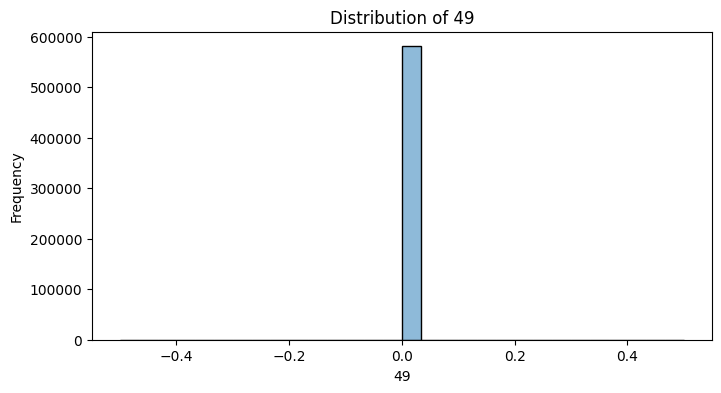

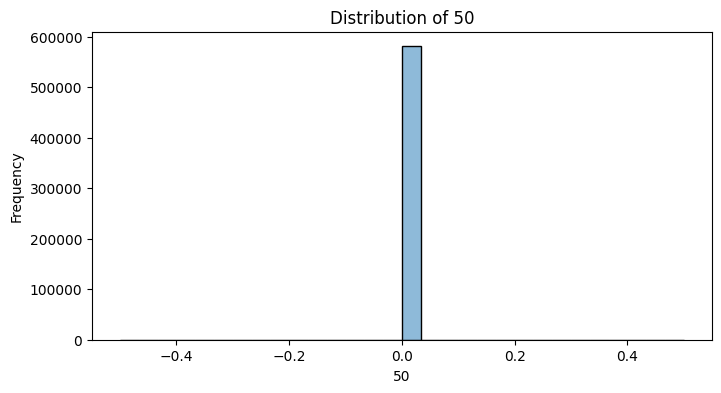

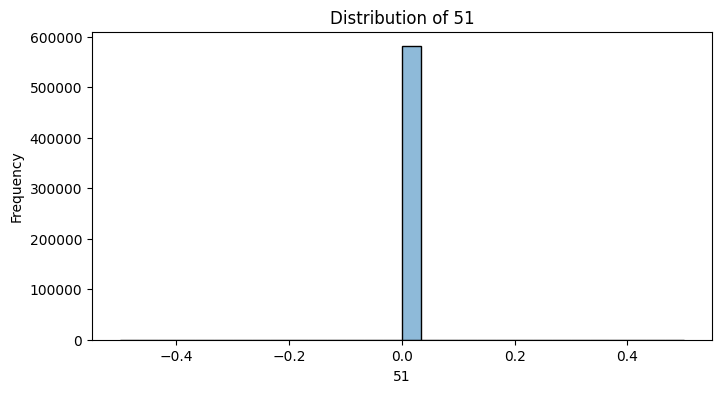

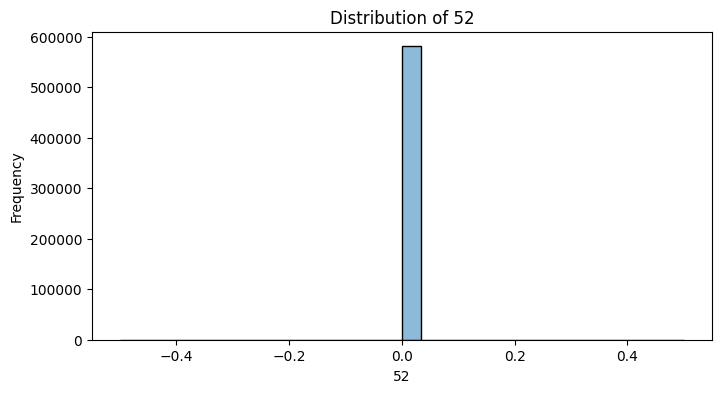

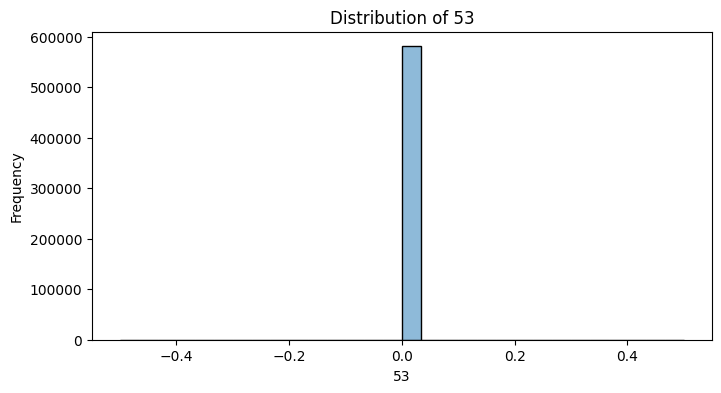

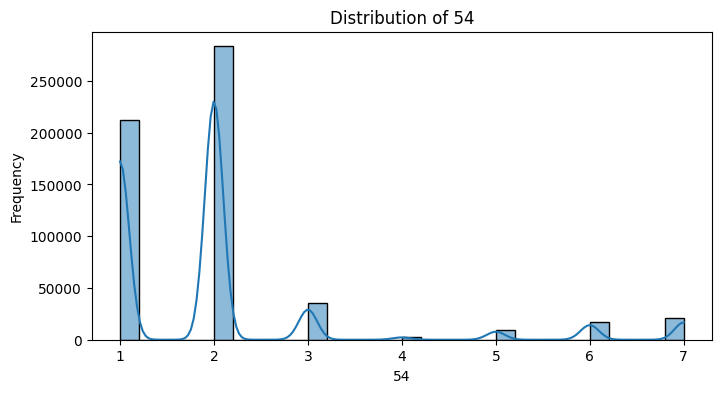

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = data_capped.select_dtypes(include='number').columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(data_capped[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


**Apply the Yeo-Johnson transformation to features with high skewness to make their distributions more symmetrical.**

In [19]:
from sklearn.preprocessing import PowerTransformer

# Make a copy to preserve the original capped data
data_transformed = data_capped.copy()

# Initialize PowerTransformer with Yeo-Johnson method
pt = PowerTransformer(method='yeo-johnson')

features_to_transform = [col for col in numeric_cols if col != target_col]
data_transformed[features_to_transform] = pt.fit_transform(data_transformed[features_to_transform])

print("Data after Yeo-Johnson transformation:")
display(data_transformed.head())

Data after Yeo-Johnson transformation:


,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,-1.332437,-0.875862,-1.877676,0.190599,-0.848354,-1.434030,0.215478,0.371431,0.120862,1.925469,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,-1.349072,-0.804208,-2.173475,-0.034644,-1.055028,-1.634268,0.167769,0.564608,0.201864,1.925469,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,-0.693129,0.081256,-0.621013,0.236619,0.485910,0.673239,0.890422,0.765231,-0.227353,1.925469,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,-0.756767,0.214532,0.640757,0.114917,1.422491,0.627154,1.119476,0.765231,-0.570748,1.925469,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,-1.335216,-0.966982,-2.173475,-0.366516,-0.879421,-1.632455,0.167769,0.499398,0.174837,1.925469,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


 re-check the skewness and distributions after the transformation

In [20]:
print("Skewness after Yeo-Johnson transformation:")
for col in features_to_transform:
    skew_val = data_transformed[col].skew()
    print(f"Skewness of {col}: {skew_val:.2f}")

Skewness after Yeo-Johnson transformation:
Skewness of 0: -0.05
Skewness of 1: -0.17
Skewness of 2: -0.03
Skewness of 3: -0.14
Skewness of 4: 0.10
Skewness of 5: -0.07
Skewness of 6: -0.13
Skewness of 7: -0.08
Skewness of 8: -0.02
Skewness of 9: -0.03
Skewness of 10: 0.21
Skewness of 11: 0.00
Skewness of 12: 0.26
Skewness of 13: 0.00
Skewness of 14: 0.00
Skewness of 15: 0.00
Skewness of 16: 0.00
Skewness of 17: 0.00
Skewness of 18: 0.00
Skewness of 19: 0.00
Skewness of 20: 0.00
Skewness of 21: 0.00
Skewness of 22: 0.00
Skewness of 23: 0.00
Skewness of 24: 0.00
Skewness of 25: 0.00
Skewness of 26: 0.00
Skewness of 27: 0.00
Skewness of 28: 0.00
Skewness of 29: 0.00
Skewness of 30: 0.00
Skewness of 31: 0.00
Skewness of 32: 0.00
Skewness of 33: 0.00
Skewness of 34: 0.00
Skewness of 35: 0.00
Skewness of 36: 0.00
Skewness of 37: 0.00
Skewness of 38: 0.00
Skewness of 39: 0.00
Skewness of 40: 0.00
Skewness of 41: 0.00
Skewness of 42: 0.00
Skewness of 43: 0.00
Skewness of 44: 0.00
Skewness of 4

**Now, let's re-plot the histogram for a few features**

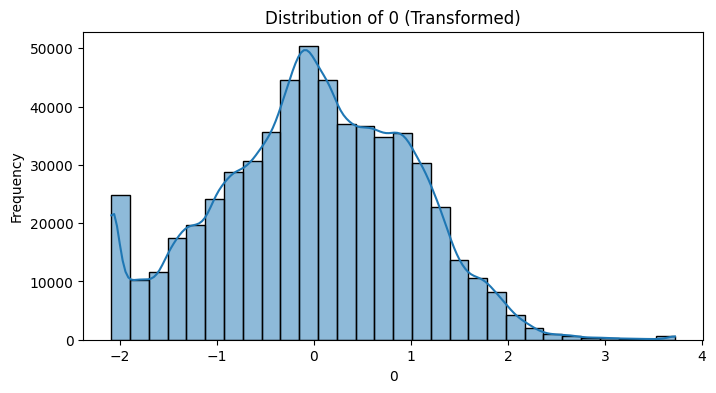

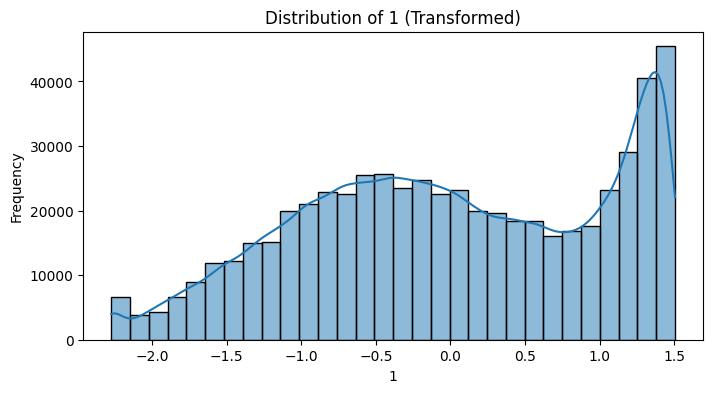

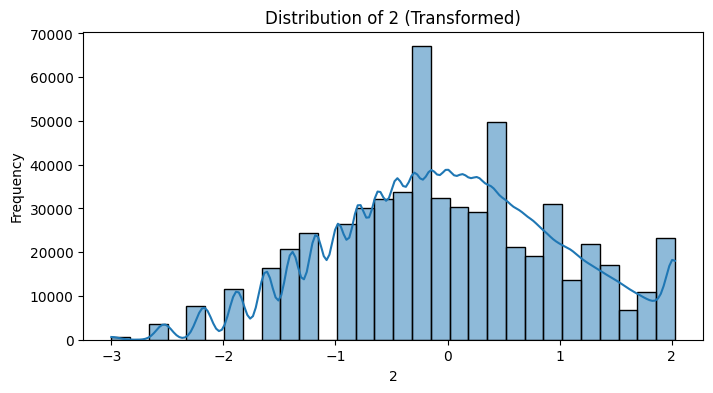

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-plot histograms for the first 3 features to see the effect of transformation
for col in features_to_transform[:3]:
    plt.figure(figsize=(8,4))
    sns.histplot(data_transformed[col], kde=True, bins=30)
    plt.title(f"Distribution of {col} (Transformed)")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Train Test split

In [23]:
X = data_transformed.drop(columns=[target_col])
y = data_transformed[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (464809, 54)
X_test shape: (116203, 54)
y_train shape: (464809,)
y_test shape: (116203,)


#XG boost model

In [26]:
from sklearn.model_selection import GridSearchCV
y_train_xgb = y_train - 1
y_test_xgb  = y_test - 1
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=7,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
print("Hyperparameter grid for XGBoost:")
print(param_grid_xgb)
grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=2,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

print("GridSearchCV for XGBoost initialized.")



Hyperparameter grid for XGBoost:
{'n_estimators': [100, 200], 'max_depth': [4, 6, 8], 'learning_rate': [0.05, 0.1], 'subsample': [0.8, 1.0], 'colsample_bytree': [0.8, 1.0]}
GridSearchCV for XGBoost initialized.


In [27]:
grid_xgb.fit(X_train, y_train_xgb)

Fitting 2 folds for each of 48 candidates, totalling 96 fits


GridSearchCV(cv=2,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=-1, num_class=7, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.05, 0.1], 'max_depth': [4, 6, 8],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='f1_weighted', verbose=2)

In [28]:
best_xgb = grid_xgb.best_estimator_

print("Best XGBoost Parameters:")
print(grid_xgb.best_params_)


Best XGBoost Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}


In [29]:
y_pred_xgb = best_xgb.predict(X_test)

In [30]:
y_pred_xgb = y_pred_xgb + 1

In [31]:
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Test Accuracy:", acc_xgb)


XGBoost Test Accuracy: 0.895019922032994


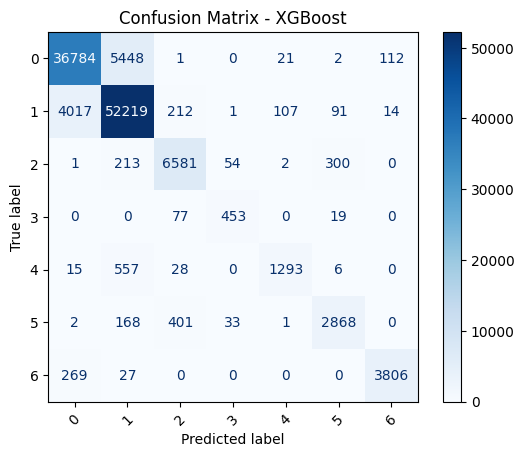

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prediction (XGBoost)
y_pred_xgb = best_xgb.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test_xgb, y_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - XGBoost")
plt.show()


In [33]:
from sklearn.metrics import accuracy_score, f1_score

# Train predictions
y_train_pred = best_xgb.predict(X_train)

# Accuracy
train_acc = accuracy_score(y_train_xgb, y_train_pred)
test_acc = accuracy_score(y_test_xgb, y_pred_xgb)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)


Train Accuracy: 0.91320520902134
Test Accuracy : 0.895019922032994


In [43]:
import pickle
# Save the trained model
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)
print("XGBoost model and scaler saved successfully!")
# Save the training data
X_train.to_csv('X_train_saved.csv', index=False)
y_train.to_csv('y_train_saved.csv', index=False)

XGBoost model and scaler saved successfully!


#RandomForest model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf=RandomForestClassifier(
    class_weight=class_weight_dict,
    random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth' : [5, 10, 15],
    'min_samples_leaf': [2, 4, 6]
}

print("Hyperparameter grid for RandomForestClassifier:")
print(param_grid)

In [ ]:
grid=GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=2,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2

)
print("GridSearchCV object initialized successfully.")

In [ ]:
grid.fit(X_train,y_train)

In [ ]:
best_rf = grid.best_estimator_

print("Best Hyperparameters:")
print(grid.best_params_)

In [ ]:
y_pred = best_rf.predict(X_test)

In [ ]:
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
train_acc = best_rf.score(X_train, y_train)
test_acc = best_rf.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

In [ ]:
# Save the trained model
with open('rf.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

In [46]:
import pandas as pd
pd.set_option('display.max_columns', None)
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54
0,2596,51,3,258,0,510,221,232,148,6279,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5


In [57]:
import gradio as gr
import pandas as pd
import pickle
# Load model
with open("xgb_model.pkl", "rb") as f:
    model = pickle.load(f)

cover_type_map = {
    1: "Spruce / Fir",
    2: "Lodgepole Pine",
    3: "Ponderosa Pine",
    4: "Cottonwood / Willow",
    5: "Aspen",
    6: "Douglas-fir",
    7: "Krummholz"
}

# Prediction function
def predict_cover(
    elevation, aspect, slope,
    hdist_hydro, vdist_hydro, hdist_road,
    hillshade_9, hillshade_noon, hillshade_3,
    hdist_fire,
    w1, w2, w3, w4,
    *soil_features
):
    features = [
        elevation, aspect, slope,
        hdist_hydro, vdist_hydro, hdist_road,
        hillshade_9, hillshade_noon, hillshade_3,
        hdist_fire,
        w1, w2, w3, w4
    ] + list(soil_features)

    X = pd.DataFrame([features])
    X_scaled = pt.transform(X)

    pred = model.predict(X_scaled)[0] + 1
    return f"🌲 Forest Cover Type: {pred} — {cover_type_map[pred]}"
# Custom CSS
custom_css = """
body {
    background: linear-gradient(to right, #0f2027, #203a43, #2c5364);
}
.gradio-container {
    font-family: 'Segoe UI', sans-serif;
}
.section {
    background-color: rgba(255, 255, 255, 0.95);
    padding: 25px;
    border-radius: 15px;
    margin-bottom: 20px;
}
.title-text {
    text-align: center;
    font-size: 34px;
    font-weight: bold;
    color: #1b5e20;
}
.subtitle-text {
    text-align: center;
    font-size: 16px;
    color: #2e7d32;
}
"""
# Gradio UI
with gr.Blocks(css=custom_css) as app:

    gr.Markdown(
        "<div class='title-text'>🌲 Forest Cover Type Prediction</div>"
        "<div class='subtitle-text'>XGBoost Model • 89% Accuracy • Manual Input UI</div>"
    )

    with gr.Column(elem_classes="section"):
        gr.Markdown("### 🌄 Topographic Features")

        elevation = gr.Number(label="Elevation (meters)")
        aspect = gr.Number(label="Aspect (degrees)")
        slope = gr.Number(label="Slope (degrees)")
        hdist_hydro = gr.Number(label="Horizontal Distance to Hydrology")
        vdist_hydro = gr.Number(label="Vertical Distance to Hydrology")
        hdist_road = gr.Number(label="Horizontal Distance to Roadways")
        hillshade_9 = gr.Number(label="Hillshade 9am")
        hillshade_noon = gr.Number(label="Hillshade Noon")
        hillshade_3 = gr.Number(label="Hillshade 3pm")
        hdist_fire = gr.Number(label="Horizontal Distance to Fire Points")

    with gr.Column(elem_classes="section"):
        gr.Markdown("### 🌲 Wilderness Areas (0 / 1)")

        w1 = gr.Radio([0,1], label="Rawah Wilderness", value=0)
        w2 = gr.Radio([0,1], label="Neota Wilderness", value=0)
        w3 = gr.Radio([0,1], label="Comanche Peak Wilderness", value=0)
        w4 = gr.Radio([0,1], label="Cache la Poudre Wilderness", value=0)

    with gr.Column(elem_classes="section"):
        gr.Markdown("### 🪨 Soil Types (Select 0 or 1)")

        soil_inputs = []
        for i in range(1, 41):
            soil_inputs.append(gr.Radio([0,1], label=f"Soil Type {i}", value=0))

    predict_btn = gr.Button("🌿 Predict Forest Cover", variant="primary")

    output = gr.Textbox(
        label="Prediction Result",
        lines=2,
        interactive=False
    )

    predict_btn.click(
        fn=predict_cover,
        inputs=[
            elevation, aspect, slope,
            hdist_hydro, vdist_hydro, hdist_road,
            hillshade_9, hillshade_noon, hillshade_3,
            hdist_fire,
            w1, w2, w3, w4,
            *soil_inputs
        ],
        outputs=output
    )

app.launch()

/tmp/ipython-input-2851814839.py:67: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css) as app:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3867c6f176a45d48ee.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
